# Polymarket Daily BTC Price-Range Markets

This notebook analyses Polymarket's "Will the price of Bitcoin be between $X and $Y on date D?" markets.

For each resolution date the order book is sliced into mutually-exclusive $2k bands.
The Yes price of each band is the market-implied probability that BTC's closing price
will fall inside that band.

**Steps**

1. Combine the per-(date, band) parquet files into two consolidated tables: one for the
   minute-by-minute Yes price history, one for the aggregated trades.
2. Build a discrete market-implied distribution of BTC closing price at every minute and
   fit a lognormal to extract implied volatility as a function of time-to-resolution.
3. Heatmap of bands coloured by market price (probability).
4. Test market efficiency: compare the market-implied probabilities at 1 day / 12 h /
   4 h before resolution against the empirical hit rate (calibration / reliability plot).


In [48]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 1. Load Data


In [49]:
COMBINED_DIR = Path('01 Data Extraction/Data/BTC Reach Daily Combined')

# prices_extended.parquet covers the full ~7-day market lifetime and includes
# the two edge bands per day (<min and >max) that complete the probability space.
# trades_extended.parquet matches the same 7-day window.
prices = pd.read_parquet('data/prices_extended.parquet')
trades = pd.read_parquet('data/trades_extended.parquet')
summaries = pd.read_parquet('data/market_summary.parquet')

## 2. Build the Yes-price panel and identify the settled band

For each market the Yes outcome carries the market-implied probability that BTC closes
inside the band.  We pivot the data into a `(date, timestamp, band)` panel of Yes prices
and recover the settlement band as the one whose Yes outcome ultimately settled at 1.


In [50]:
# Yes-only minute-by-minute panel
yes = prices[prices["outcome_label"] == "Yes"].copy()
yes["band_mid"] = (yes["lower_price"] + yes["upper_price"]) / 2.0
yes["target_date"] = pd.to_datetime(yes["target_date"], utc=True).dt.normalize()
yes["timestamp"] = pd.to_datetime(yes["timestamp"], utc=True)
yes["minutes_to_resolution"] = (
    (yes["market_end_date"] - yes["timestamp"]).dt.total_seconds() / 60.0
)

# Fix band_mid for edge bands: use the finite bound as the reference price
# <Xk band: lower=0, upper=X → mid = X/2 (proxy, not used in centred analysis)
# >Xk band: lower=X, upper=10M → mid = X*1.5 (proxy)
UPPER_SENTINEL = 1_000_000
edge_lower_mask = yes["lower_price"] == 0
edge_upper_mask = yes["upper_price"] >= UPPER_SENTINEL
yes.loc[edge_lower_mask, "band_mid"] = yes.loc[edge_lower_mask, "upper_price"] / 2
yes.loc[edge_upper_mask, "band_mid"] = yes.loc[edge_upper_mask, "lower_price"] * 1.5

print(f"Yes panel : {yes.shape[0]:,} rows")
print(f"Dates     : {yes['target_date'].nunique()}  "
      f"({yes['target_date'].min().date()} -> {yes['target_date'].max().date()})")
print(f"Bands/day : {yes.groupby('target_date')['price_band_label'].nunique().describe().round(2).to_dict()}")

# Settlement: the Yes outcome row whose final outcome_price == 1
settle = (yes.groupby(["target_date", "price_band_label"], as_index=False)
              .agg(lower_price=("lower_price", "first"),
                   upper_price=("upper_price", "first"),
                   band_mid=("band_mid", "first"),
                   outcome_price=("outcome_price", "last")))
winners = settle[settle["outcome_price"] == 1]
print(f"\nResolved days with a winning band: {winners['target_date'].nunique()}")

# Per-day settlement summary: only from finite bands (edge bands could win but
# band_mid is a proxy and would break the centred-heatmap analysis)
settled_band = (winners
                .loc[(winners["lower_price"] > 0) & (winners["upper_price"] < UPPER_SENTINEL)]
                .set_index("target_date")
                [["price_band_label", "lower_price", "upper_price", "band_mid"]]
                .rename(columns={"price_band_label": "settled_band",
                                  "lower_price": "settled_lower",
                                  "upper_price": "settled_upper",
                                  "band_mid": "settled_mid"}))
settled_band.head()

Yes panel : 8,860,533 rows
Dates     : 81  (2025-11-01 -> 2026-01-21)
Bands/day : {'count': 81.0, 'mean': 10.91, 'std': 0.45, 'min': 8.0, '25%': 11.0, '50%': 11.0, '75%': 11.0, 'max': 11.0}

Resolved days with a winning band: 80


,settled_band,settled_lower,settled_upper,settled_mid
target_date,,,,
2025-11-01 00:00:00+00:00,110k-112k,110000.0,112000.0,111000.0
2025-11-02 00:00:00+00:00,110k-112k,110000.0,112000.0,111000.0
2025-11-03 00:00:00+00:00,106k-108k,106000.0,108000.0,107000.0
2025-11-05 00:00:00+00:00,102k-104k,102000.0,104000.0,103000.0
2025-11-06 00:00:00+00:00,100k-102k,100000.0,102000.0,101000.0


### 2.b Trade volume vs time-to-resolution — lookback choice

Polymarket daily BTC range markets are open for approximately **7 days** before
resolution. Both `prices_extended.parquet` and `trades_extended.parquet` now cover
this entire window ($\approx 168\,\text{h}$).  Each day has **11 markets**: 9 finite
$2\,\text{k}$ bands centred on the current BTC price, plus one **"less than"** band
(lower tail) and one **"greater than"** band (upper tail) that together ensure the
band probabilities sum to 1.

The plot below shows how trading volume ($\text{USDC}$) is distributed across
the full 168 h before resolution. This informs our choice of temporal bins:

* **Fine 4 h bins** for the last 24 h, where volume is concentrated
  (the last 4 h alone account for ~59 % of all volume).
* **Coarser bins** beyond 24 h (`[24,48)`, `[48,72)`, `[72,120)`, `[120,168)`)
  where the term structure of implied volatility and the smile shape are still
  identifiable from CLOB price history.

Median daily 7-day total USDC volume: $86,758
Volume share: last  4 h = 52.6%
Volume share: last 24 h = 90.1%
Volume share: full 168 h = 100.0%

Chosen temporal bins:
  Fine  (0–24 h):    [0,4), [4,8), [8,12), [12,16), [16,20), [20,24) h
  Coarse (24–168 h): [24,48), [48,72), [72,120), [120,168) h


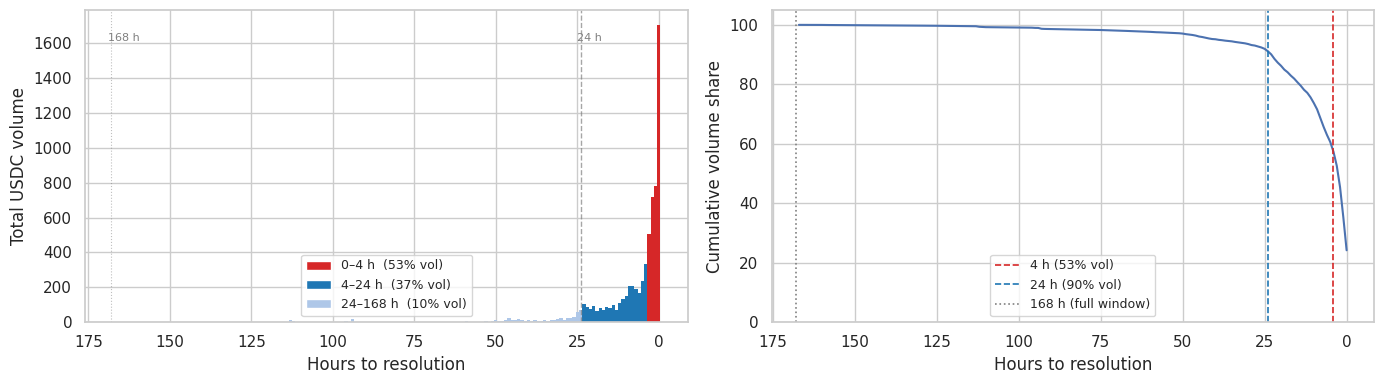

In [51]:
# ── Volume per hour bin, aggregated over all days and bands ─────────────────
yes_t = trades[trades["outcome_label"] == "Yes"].copy()
yes_t["ttr_h"] = (yes_t["market_end_date"] - yes_t["timestamp"]).dt.total_seconds() / 3600.0

# Bin into integer-hour buckets capped at 167 (full 7-day window)
MAX_HOURS = 168
yes_t["ttr_bin_h"] = yes_t["ttr_h"].clip(0, MAX_HOURS - 1).astype(int)

vol_by_hour = (yes_t.groupby("ttr_bin_h")["volume_usdc"].sum()
                    .reindex(range(MAX_HOURS), fill_value=0)
                    .sort_index())
total_vol = vol_by_hour.sum()
cum_from_res = vol_by_hour.sort_index().cumsum()

# Colour coding: red = last 4 h, blue = 4–24 h, light blue = 24–168 h
def _bar_color(h):
    if h < 4:
        return "#d62728"
    if h < 24:
        return "#1f77b4"
    return "#aec7e8"

colors = [_bar_color(h) for h in vol_by_hour.index]

pct4  = vol_by_hour[:4].sum()  / total_vol * 100
pct24 = vol_by_hour[:24].sum() / total_vol * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(vol_by_hour.index, vol_by_hour.values / 1e3,
       color=colors, edgecolor="none", width=1.0)
ax.invert_xaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Total USDC volume")

# Annotation for last-4-h share
y_ann = vol_by_hour[:4].sum() / 1e3 * 0.55
ax.annotate(f"{pct4:.0f}% of volume\nin last 4 h",
            xy=(2, y_ann), xytext=(20, y_ann * 1.4),
            fontsize=9, color="#d62728",
            arrowprops=dict(arrowstyle="-|>", color="#d62728"))
# Vertical lines at 24 h and 168 h
ax.axvline(24,  color="grey",   ls="--", lw=1.0, alpha=0.7)
ax.axvline(168, color="grey",   ls=":",  lw=0.8, alpha=0.5)
ax.text(25, ax.get_ylim()[1] * 0.9, "24 h", color="grey", fontsize=8, ha="left")
ax.text(169, ax.get_ylim()[1] * 0.9, "168 h", color="grey", fontsize=8, ha="left")

# Patches for legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label=f"0–4 h  ({pct4:.0f}% vol)"),
    Patch(facecolor="#1f77b4", label=f"4–24 h  ({pct24-pct4:.0f}% vol)"),
    Patch(facecolor="#aec7e8", label=f"24–168 h  ({100-pct24:.0f}% vol)"),
]
ax.legend(handles=legend_elements, fontsize=9)

ax = axes[1]
ax.plot(cum_from_res.index, cum_from_res.values / total_vol * 100,
        "-", color="C0", lw=1.5)
ax.axvline(4,   color="#d62728", ls="--", lw=1.2,
           label=f"4 h ({pct4:.0f}% vol)")
ax.axvline(24,  color="#1f77b4", ls="--", lw=1.2,
           label=f"24 h ({pct24:.0f}% vol)")
ax.axvline(168, color="grey",    ls=":",  lw=1.2,
           label="168 h (full window)")
ax.invert_xaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Cumulative volume share")

ax.legend(fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('volume_poly', dpi = 200, transparent = True)

print(f"Median daily 7-day total USDC volume: ${yes_t.groupby('target_date')['volume_usdc'].sum().median():,.0f}")
print(f"Volume share: last  4 h = {pct4:.1f}%")
print(f"Volume share: last 24 h = {pct24:.1f}%")
print(f"Volume share: full 168 h = 100.0%")
print()
print("Chosen temporal bins:")
print("  Fine  (0–24 h):    [0,4), [4,8), [8,12), [12,16), [16,20), [20,24) h")
print("  Coarse (24–168 h): [24,48), [48,72), [72,120), [120,168) h")

In [52]:
# Extended temporal bins used throughout the rest of this notebook.
# Calibration (Section 5) is restricted to the first six 4-h bins where trade
# data is available; all other analyses use the full extended window.
BUCKET_EDGES_FINE     = [0, 4, 8, 12, 16, 20, 24]           # trade-data window
BUCKET_EDGES_EXTENDED = [0, 4, 8, 12, 16, 20, 24, 48, 72, 120, 168]  # full market lifetime

# Convenience: list of (lo_h, hi_h, label) for each bucket
lookbacks_fine     = [(lo, hi, f"{lo}-{hi} h")
                      for lo, hi in zip(BUCKET_EDGES_FINE[:-1],     BUCKET_EDGES_FINE[1:])]
lookbacks_extended = [(lo, hi, f"{lo}-{hi} h")
                      for lo, hi in zip(BUCKET_EDGES_EXTENDED[:-1], BUCKET_EDGES_EXTENDED[1:])]

# For the smile + calibration we expose a single `lookbacks` variable; each
# consumer overrides it locally when it needs the other set.
lookbacks = lookbacks_extended

def snapshot_in_window(lo_h, hi_h, src_df=None):
    """Average Yes price per (date, band) across all snapshots with ttr in [lo_h, hi_h)."""
    df = yes_15m if src_df is None else src_df
    ttr_h = df["minutes_to_resolution"] / 60.0
    g = df[(ttr_h >= lo_h) & (ttr_h < hi_h)]
    if g.empty:
        return g.iloc[0:0].copy()
    return (g.groupby(["target_date", "lower_price", "upper_price"], as_index=False)
              .agg(price=("price", "mean"),
                   n_minutes=("price", "size")))


## 3. Heatmap of bands coloured by Yes price

The colour of cell `(t, band)` is the market-implied probability that BTC closes inside
that band, where `t` is the time-to-resolution (in hours) and bands are stacked by their
lower price.  We plot four representative days and one aggregate view in which bands have
been re-centred on the eventually-realised band so cross-day averages are meaningful.


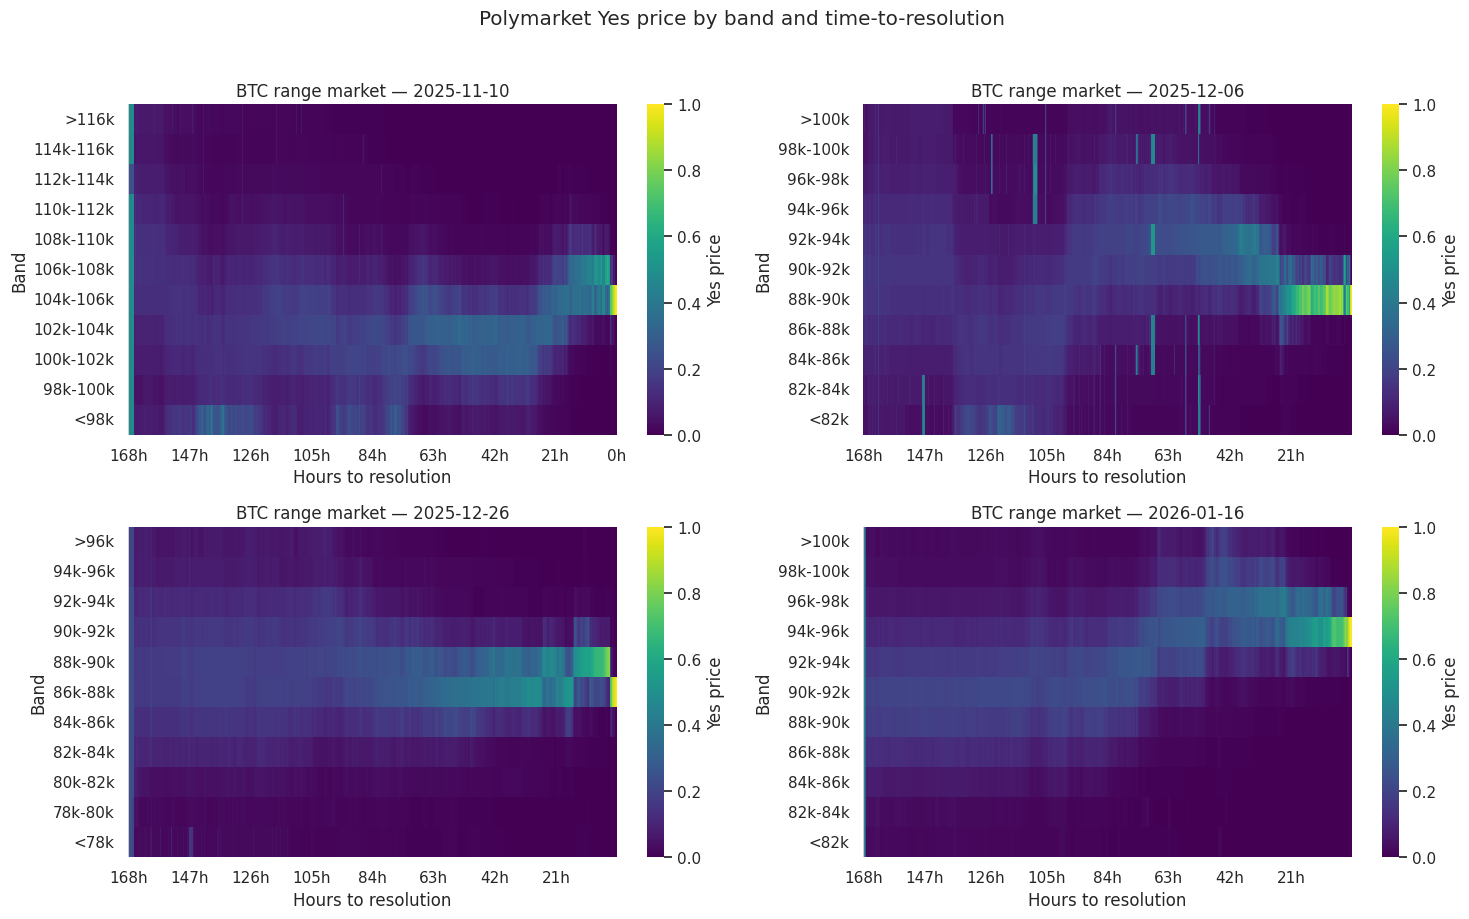

In [53]:
# Resample to a coarser grid so heatmaps render quickly: 15-minute buckets
yes_15m = yes.copy()
yes_15m["ttr_h"] = yes_15m["minutes_to_resolution"] / 60.0
yes_15m["ttr_bin"] = (yes_15m["ttr_h"] / 0.25).round() * 0.25  # 15 min

def _day_heatmap(day, ax):
    g = yes_15m[yes_15m["target_date"] == day]
    pivot = (g.groupby(["lower_price", "ttr_bin"])["price"]
              .mean().unstack("ttr_bin"))
    pivot = pivot.sort_index(ascending=True)
    # Sort columns by ttr descending so the resolution moment is on the right
    pivot = pivot[sorted(pivot.columns, reverse=True)]

    # Build y-axis labels from actual price_band_label in the data
    label_lookup = (g.groupby("lower_price")["price_band_label"]
                     .first().to_dict())
    yticks = [label_lookup.get(lo, f"{int(lo/1000)}k") for lo in pivot.index]

    sns.heatmap(pivot.values, ax=ax, cmap="viridis", vmin=0, vmax=1,
                cbar_kws={"label": "Yes price"})
    ax.set_yticks(np.arange(len(yticks)) + 0.5)
    ax.set_yticklabels(yticks, rotation=0)
    # x-ticks: show every ~4h
    cols = pivot.columns.to_numpy()
    step = max(1, len(cols) // 8)
    ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
    ax.set_xticklabels([f"{c:.0f}h" for c in cols[::step]], rotation=0)
    ax.invert_yaxis()
    ax.set_xlabel("Hours to resolution")
    ax.set_ylabel("Band")
    ax.set_title(f"BTC range market — {pd.Timestamp(day).date()}")

sample_days = (settled_band.index
               .intersection(yes_15m["target_date"].unique()))
# Pick four well-separated days
sample_days = sorted(sample_days)
sample_days = [sample_days[i] for i in np.linspace(5, len(sample_days)-5, 4).astype(int)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for d, ax in zip(sample_days, axes.ravel()):
    _day_heatmap(d, ax)
fig.suptitle("Polymarket Yes price by band and time-to-resolution", y=1.02)
fig.tight_layout()
plt.show()

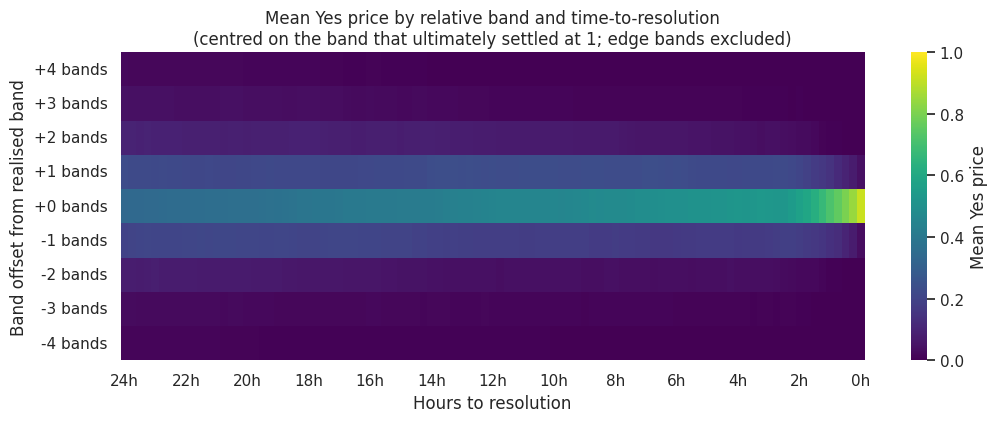

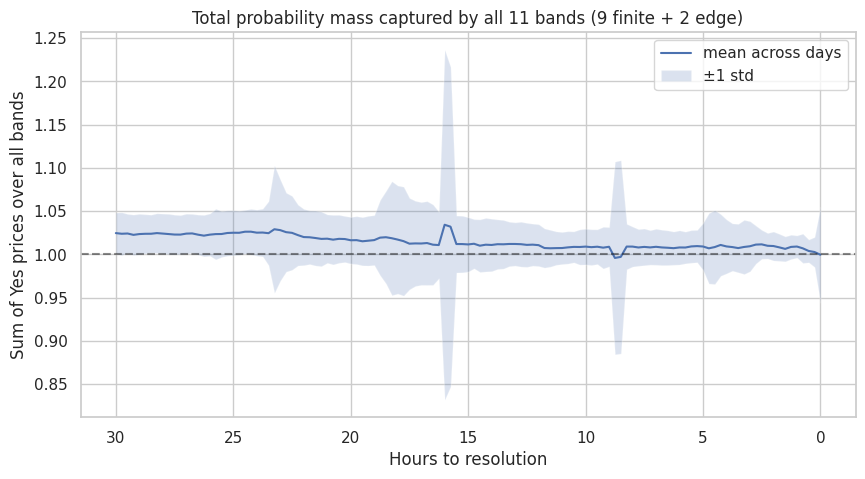

In [56]:
# Aggregate heatmap: re-centre bands on the eventually-realised band so we can
# average across days.  The y-axis is the band offset (in $2k steps) from the
# winning band; the colour is the average Yes price across the days where that
# relative band existed.
# Edge bands (<min and >max) are excluded from the centred view because their
# band_mid does not represent the typical $2k-step grid.

# Exclude edge bands (lower_price == 0 or upper_price >= UPPER_SENTINEL) from centring
yes_15m_finite = yes_15m[
    (yes_15m["lower_price"] > 0) & (yes_15m["upper_price"] < 1_000_000)
].copy()

resolved_yes = yes_15m_finite.merge(
    settled_band[["settled_mid"]], left_on="target_date", right_index=True, how="inner")
resolved_yes["rel_band"] = ((resolved_yes["band_mid"] - resolved_yes["settled_mid"]) / 2000).round().astype(int)

agg = (resolved_yes.groupby(["rel_band", "ttr_bin"])["price"]
                   .mean().unstack("ttr_bin"))
agg = agg.sort_index()
agg = agg[sorted(agg.columns, reverse=True)]

# Restrict to dense region
agg = agg.loc[(agg.index >= -4) & (agg.index <= 4)]
agg = agg.loc[:, agg.columns <= 24]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(agg.values, ax=ax, cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "Mean Yes price"})
cols = agg.columns.to_numpy()
step = max(1, len(cols) // 12)
ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
ax.set_xticklabels([f"{c:.0f}h" for c in cols[::step]], rotation=0)
ax.set_yticks(np.arange(len(agg.index)) + 0.5)
ax.set_yticklabels([f"{b:+d} bands" for b in agg.index], rotation=0)
ax.invert_yaxis()
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Band offset from realised band")
ax.set_title("Mean Yes price by relative band and time-to-resolution\n"
             "(centred on the band that ultimately settled at 1; edge bands excluded)")
plt.show()

# Sanity check: probabilities should sum to ~1 across all bands (incl. edge) at each instant.
band_sum = (yes_15m.groupby(["target_date", "ttr_bin", "lower_price"])["price"].mean()
                   .groupby(["target_date", "ttr_bin"]).sum()
                   .groupby("ttr_bin").agg(["mean", "std"]))
band_sum = band_sum.sort_index()
band_sum = band_sum[band_sum.index.to_series().between(0, 30)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(band_sum.index, band_sum["mean"], label="mean across days")
ax.fill_between(band_sum.index,
                band_sum["mean"] - band_sum["std"],
                band_sum["mean"] + band_sum["std"], alpha=0.2,
                label="±1 std")
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Sum of Yes prices over all bands")
ax.set_title("Total probability mass captured by all 11 bands (9 finite + 2 edge)")
ax.legend()
ax.invert_xaxis()
plt.savefig('prob_mass_poly',dpi = 200, transparent = True, bbox_inches = "tight")

## 4. Implied volatility vs time-to-resolution

At every minute Polymarket gives us a discrete CDF of BTC's closing price.  Fitting a
lognormal $\ln S_T \sim \mathcal{N}(\mu, \sigma^2)$ to those band probabilities lets us
recover an implied volatility:

$$ p_i \approx \Phi\!\left(\frac{\ln U_i - \mu}{\sigma}\right) - \Phi\!\left(\frac{\ln L_i - \mu}{\sigma}\right). $$

We minimise the sum of squared errors over the bands at every 15-minute snapshot, then
annualise with $\sigma_{\text{IV}} = \sigma / \sqrt{\tau_y}$.


In [57]:
def fit_lognormal(lowers, uppers, probs):
    """Return (mu, sigma) minimising squared distance between bands and lognormal."""
    lowers = np.asarray(lowers, dtype=float)
    uppers = np.asarray(uppers, dtype=float)
    probs = np.asarray(probs, dtype=float)
    ln_lo = np.log(np.maximum(lowers, 1.0))
    ln_hi = np.log(uppers)
    # Spot guess: probability-weighted band mid
    mid = (lowers + uppers) / 2.0
    s = probs.sum()
    spot = float((mid * probs).sum() / s) if s > 0 else float(mid.mean())
    mu0 = np.log(spot)
    sig0 = 0.02
    def loss(theta):
        mu, log_sig = theta
        sig = np.exp(log_sig)
        cdf_hi = norm.cdf((ln_hi - mu) / sig)
        cdf_lo = norm.cdf((ln_lo - mu) / sig)
        pred = cdf_hi - cdf_lo
        return float(np.sum((pred - probs) ** 2))
    res = minimize(loss, x0=[mu0, np.log(sig0)], method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-8, "maxiter": 400})
    mu, log_sig = res.x
    return mu, float(np.exp(log_sig)), res.fun


# Aggregate to one row per (target_date, ttr_bin, band)
snap = (yes_15m.groupby(["target_date", "ttr_bin", "lower_price", "upper_price"],
                        as_index=False)["price"].mean())

# Need market_end_date per (target_date, ttr_bin) -> ttr_bin already encodes time-to-resolution.
# Only fit snapshots where:
#   - there is non-trivial probability mass (sum>0.5)
#   - we have at least 4 bands
#   - 0 < ttr_h < 30
fit_records = []
groups = snap.groupby(["target_date", "ttr_bin"])
for (day, ttr_h), g in groups:
    # Cap IV fit at 48 h: beyond that the 4-h-bin resolution yields the same
    # information as the smile bucket analysis, while fitting every bin out to
    # 168 h would require ~15 min of compute.
    if ttr_h <= 0 or ttr_h > 48:
        continue
    if len(g) < 4 or g["price"].sum() < 0.5:
        continue
    mu, sigma, err = fit_lognormal(g["lower_price"].values,
                                   g["upper_price"].values,
                                   g["price"].values)
    fit_records.append({
        "target_date": day,
        "ttr_h": ttr_h,
        "mu": mu,
        "spot_implied": np.exp(mu),
        "sigma_h": sigma,
        "fit_err": err,
        "prob_mass": g["price"].sum(),
    })

iv = pd.DataFrame(fit_records)
iv["tau_years"] = iv["ttr_h"] / 24.0 / 365.0
iv["iv_annual"] = iv["sigma_h"] / np.sqrt(iv["tau_years"])
print(f"Fitted {len(iv):,} snapshots across {iv['target_date'].nunique()} days")
iv.head()


Fitted 15,544 snapshots across 81 days


,target_date,ttr_h,mu,spot_implied,sigma_h,fit_err,prob_mass,tau_years,iv_annual
0,2025-11-01 00:00:00+00:00,0.25,11.611457,110354.902883,0.005035,0.000004,1.001467,0.000029,0.942576
1,2025-11-01 00:00:00+00:00,0.50,11.610786,110280.935444,0.005456,0.000006,1.001300,0.000057,0.722111
2,2025-11-01 00:00:00+00:00,0.75,11.613187,110545.959505,0.004817,0.000011,1.001700,0.000086,0.520554
3,2025-11-01 00:00:00+00:00,1.00,11.607058,109870.531654,0.005342,0.000012,1.010300,0.000114,0.499969
4,2025-11-01 00:00:00+00:00,1.25,11.606448,109803.541048,0.005360,0.000010,1.009633,0.000143,0.448746


IV at   48h to resolution: 27.0%  (n=81 snapshots)
IV at   24h to resolution: 38.2%  (n=81 snapshots)
IV at   12h to resolution: 41.4%  (n=81 snapshots)
IV at    4h to resolution: 49.5%  (n=81 snapshots)
IV at    1h to resolution: 68.0%  (n=81 snapshots)


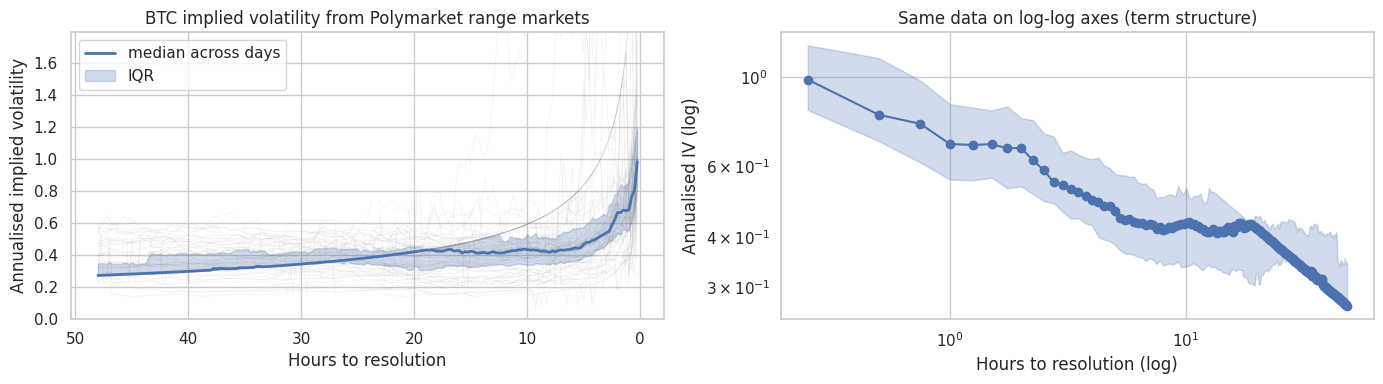

In [59]:
# Plot IV vs time-to-resolution.  We aggregate across days into the median and
# inter-quartile band per ttr bin.
iv_q = (iv.groupby("ttr_h")["iv_annual"]
          .agg(median="median", q25=lambda s: s.quantile(0.25),
               q75=lambda s: s.quantile(0.75), n="count")
          .reset_index())
iv_q = iv_q[iv_q["n"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for d, g in iv.groupby("target_date"):
    ax.plot(g["ttr_h"], g["iv_annual"], color="grey", alpha=0.1, lw=0.5)
ax.plot(iv_q["ttr_h"], iv_q["median"], color="C0", lw=2, label="median across days")
ax.fill_between(iv_q["ttr_h"], iv_q["q25"], iv_q["q75"], color="C0", alpha=0.25,
                label="IQR")
ax.set_xlabel("Hours to resolution")
ax.set_ylabel("Annualised implied volatility")
ax.set_title("BTC implied volatility from Polymarket range markets")
ax.set_ylim(0, min(2.5, iv_q["q75"].max() * 1.5))
ax.invert_xaxis()
ax.legend()

ax = axes[1]
ax.plot(iv_q["ttr_h"], iv_q["median"], "o-", color="C0")
ax.fill_between(iv_q["ttr_h"], iv_q["q25"], iv_q["q75"], color="C0", alpha=0.25)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Hours to resolution (log)")
ax.set_ylabel("Annualised IV (log)")
ax.set_title("Same data on log-log axes (term structure)")

plt.tight_layout()
plt.savefig("term_structure", dpi = 200, transparent = True)

for ref_h in [48, 24, 12, 4, 1]:
    row = iv_q.loc[(iv_q["ttr_h"] - ref_h).abs().idxmin()]
    print(f"IV at {ref_h:4d}h to resolution: {row['median']*100:.1f}%  (n={int(row['n'])} snapshots)")


### 4.b Why a lognormal? Link with implied volatility in options, and richer fits

**Why lognormal first.**  The lognormal is the canonical baseline because (i) it is the
benchmark distribution of the Black–Scholes model (GBM dynamics
$dS/S = \mu\,dt + \sigma\,dW$), (ii) it has only two parameters (location and scale),
which exactly matches what one can identify from a *single* implied vol number, and
(iii) for short horizons ($\tau \lesssim 1\text{d}$) it is a very good local
approximation to virtually any continuous price process – higher moments only become
material on longer horizons.

**Link with traditional implied volatility.**  In options markets, an *implied
volatility* is the unique $\sigma$ that makes the Black–Scholes price equal the
observed option price.  Here we do something equivalent but with *digital* payoffs:
a Polymarket "Yes" contract on band $[L,U]$ is economically a *butterfly* of two
digital calls:

$$\text{Yes}_{[L,U]} = \mathbf{1}\{S_T>L\} - \mathbf{1}\{S_T>U\}.$$

Under Black-Scholes with zero rate, a digital call on $K$ has price
$N(d_2(K,\sigma))$, so the band price is
$N(d_2(L,\sigma)) - N(d_2(U,\sigma))$.  Fitting a single $\sigma$ to *all* bands is
exactly fitting the lognormal CDF, and the resulting number is directly comparable to
the at-the-money implied vol on a CME / Deribit BTC option of the same maturity.  If
the bands disagree on $\sigma$ – the *smile* – the market is telling us BTC's risk-
neutral distribution is non-lognormal (heavy tails, skew, …).

**Going beyond two parameters.**  We extend the fit with a *skew-normal on
log-returns*: $\ln S_T \sim \mathrm{SN}(\xi, \omega, \alpha)$.  The third parameter
$\alpha$ captures skewness; positive $\alpha$ means more mass in the right tail.  A
Johnson-$S_U$ (4 parameters) would additionally capture excess kurtosis, but with
only 9 band probabilities per snapshot the skew-normal is already at the edge of
identifiability.


skew-normal fit:   0%|          | 0/13658 [00:00<?, ?snap/s]

Mean SSE  lognormal  : 0.19148
Mean SSE  skew-normal: 0.01114
Skew-normal strictly improves on 63.3% of snapshots


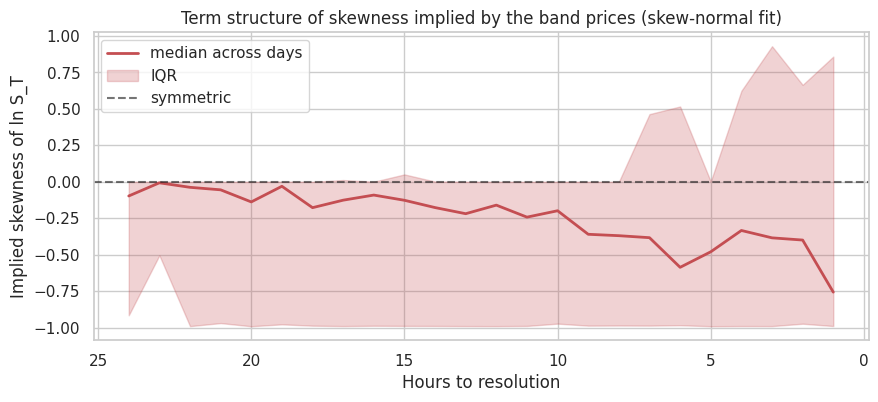

In [61]:
from scipy.special import owens_t
from tqdm.auto import tqdm

# Fast closed-form skew-normal CDF: F(x; xi, omega, alpha) = Phi(z) - 2 T(z, alpha),
# z = (x - xi)/omega.  scipy.stats.skewnorm.cdf silently falls back to numerical
# integration in the tails (a>0, cdf<1e-6); replacing it with this vectorised
# expression makes a single evaluation ~1 µs instead of ~ms.
def _sn_cdf(x, xi, omega, alpha):
    z = (x - xi) / omega
    return norm.cdf(z) - 2.0 * owens_t(z, alpha)


def _moment_init(lowers, uppers, probs):
    """Method-of-moments seed for the skew-normal fit (on ln S_T)."""
    ln_mid = (np.log(np.maximum(lowers, 1.0)) + np.log(uppers)) / 2.0
    s = probs.sum()
    if s <= 0:
        return np.log((lowers.mean() + uppers.mean()) / 2), 0.02, 0.0
    w = probs / s
    m = float((w * ln_mid).sum())
    v = float((w * (ln_mid - m) ** 2).sum())
    sd = max(np.sqrt(max(v, 1e-12)), 1e-6)
    g = float((w * ((ln_mid - m) / sd) ** 3).sum())          # sample skewness
    target = np.clip(abs(g), 1e-3, 0.99)
    ds = np.linspace(1e-3, 0.999, 200)
    gs = ((4 - np.pi) / 2) * (ds * np.sqrt(2/np.pi)) ** 3 \
         / (1 - 2 * ds ** 2 / np.pi) ** 1.5
    delta = float(np.sign(g) * ds[np.abs(gs - target).argmin()])
    alpha = delta / np.sqrt(max(1 - delta ** 2, 1e-9))
    omega = sd / np.sqrt(max(1 - 2 * delta ** 2 / np.pi, 1e-6))
    xi = m - omega * delta * np.sqrt(2 / np.pi)
    return xi, omega, alpha


def fit_skewnormal(lowers, uppers, probs):
    """Fit ln S_T ~ SkewNormal(xi, omega, alpha) to band probabilities."""
    lowers = np.asarray(lowers, float); uppers = np.asarray(uppers, float)
    probs = np.asarray(probs, float)
    ln_lo = np.log(np.maximum(lowers, 1.0)); ln_hi = np.log(uppers)
    xi0, om0, al0 = _moment_init(lowers, uppers, probs)

    def loss(theta):
        xi, log_om, alpha = theta
        om = np.exp(log_om)
        pred = _sn_cdf(ln_hi, xi, om, alpha) - _sn_cdf(ln_lo, xi, om, alpha)
        return float(np.sum((pred - probs) ** 2))

    x0 = [xi0, np.log(max(om0, 1e-4)), float(al0)]
    res = minimize(loss, x0, method="Nelder-Mead",
                   options={"xatol": 1e-5, "fatol": 1e-9, "maxiter": 300})
    xi, log_om, alpha = res.x
    return xi, float(np.exp(log_om)), float(alpha), float(res.fun)


# Subsample: fit one snapshot per hour to keep the cell quick.
snap_h = snap.copy()
snap_h["ttr_h_int"] = snap_h["ttr_bin"].round().astype(int)
snap_h = (snap_h.groupby(["target_date", "ttr_h_int", "lower_price", "upper_price"],
                         as_index=False)["price"].mean())

snap_groups = list(snap_h.groupby(["target_date", "ttr_h_int"]))
sn_records = []
for (day, ttr_h), g in tqdm(snap_groups, desc="skew-normal fit", unit="snap"):
    if ttr_h <= 0 or ttr_h > 24 or len(g) < 5 or g["price"].sum() < 0.5:
        continue
    xi, om, alpha, err = fit_skewnormal(g["lower_price"].values,
                                        g["upper_price"].values,
                                        g["price"].values)
    delta = alpha / np.sqrt(1 + alpha ** 2)
    g_sn = ((4 - np.pi) / 2) * (delta * np.sqrt(2/np.pi)) ** 3 \
           / max((1 - 2 * delta ** 2 / np.pi) ** 1.5, 1e-9)
    sn_records.append({"target_date": day, "ttr_h": float(ttr_h),
                       "xi": xi, "omega": om, "alpha": alpha,
                       "skewness_logS": g_sn, "fit_err": err})

iv_sn = pd.DataFrame(sn_records)
iv_sn["tau_years"] = iv_sn["ttr_h"] / 24.0 / 365.0
iv_sn["iv_annual_sn"] = iv_sn["omega"] / np.sqrt(iv_sn["tau_years"])

# Compare fit quality vs the lognormal on the matching subsampled grid
iv_h = (iv.assign(ttr_h_int=iv["ttr_h"].round().astype(int))
          .groupby(["target_date", "ttr_h_int"], as_index=False)
          .agg(fit_err_logn=("fit_err", "mean")))
cmp = iv_sn.merge(iv_h, left_on=["target_date", "ttr_h"],
                  right_on=["target_date", "ttr_h_int"], how="inner")
print(f"Mean SSE  lognormal  : {cmp['fit_err_logn'].mean():.5f}")
print(f"Mean SSE  skew-normal: {cmp['fit_err'].mean():.5f}")
print(f"Skew-normal strictly improves on {(cmp['fit_err'] < cmp['fit_err_logn']-1e-6).mean()*100:.1f}% of snapshots")

# Term structure of implied skewness
sk_q = (iv_sn.groupby("ttr_h")["skewness_logS"]
              .agg(median="median",
                   q25=lambda s: s.quantile(0.25),
                   q75=lambda s: s.quantile(0.75),
                   n="count").reset_index())
sk_q = sk_q[sk_q["n"] >= 10]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sk_q["ttr_h"], sk_q["median"], lw=2, color="C3", label="median across days")
ax.fill_between(sk_q["ttr_h"], sk_q["q25"], sk_q["q75"], color="C3", alpha=0.25,
                label="IQR")
ax.axhline(0, color="k", linestyle="--", alpha=0.6, label="symmetric")
ax.set_xlabel("Hours to resolution"); ax.set_ylabel("Implied skewness of ln S_T")
ax.set_title("Term structure of skewness implied by the band prices (skew-normal fit)")
ax.invert_xaxis(); ax.legend()
plt.savefig('skewness_plot', dpi = 200, transparent = True)


### 4.c Implied volatility smile

The lognormal fit collapses the whole band structure onto a single $\sigma$.  If the
market really thinks BTC is lognormal, every band must imply the *same* $\sigma$ —
the "smile" is flat.  We invert each band boundary one by one and plot
$\sigma_{\text{BS}}(K)$ as a function of log-moneyness $m=\ln(K/S_t)$.

For a digital call paying \$1 if $S_T>K$, Black–Scholes with zero rate gives the
price $N(d_2)$ with $d_2 = \bigl(\ln(S/K) - \tfrac12\sigma^2\tau\bigr)/(\sigma\sqrt\tau)$.
Given the empirical right-tail probability $P_K = \sum_{L_i\ge K} p_i$ from the
bands, we numerically invert for the $\sigma$ that reproduces it.  We use $S_t$ from
the lognormal fit (`spot_implied`) as the spot.

**What we can learn about Polymarket users**

* The number we recover is a *risk-neutral* IV only if Polymarket prices satisfy a
  no-arbitrage replication argument.  In a betting market with no funding cost and
  no ability to delta-hedge, prices are the *belief-weighted average willingness to
  pay*, not a strict risk-neutral expectation.
* A **smile** (vol higher on both wings) means traders price tails *fatter* than
  lognormal — consistent with prospect-theory overweighting of small probabilities
  (Tversky & Kahneman), or with genuine belief in jumps / heavy tails for BTC.
* A **skew/smirk** (vol higher on one side) measures asymmetric beliefs.  In equity
  options this is normally a *put skew* (left wing high) reflecting crash risk; in
  BTC it tends to invert during bullish regimes.  Whatever sign we see here is a
  direct read of Polymarket traders' subjective skew.
* A **flat smile** would mean Polymarket users are effectively lognormal believers
  *and* not strongly distorting tail probabilities — i.e. their pricing is close to
  the historical/physical distribution of overnight BTC returns.


5,259 (date, strike) IV points across 79 days, in 10 buckets


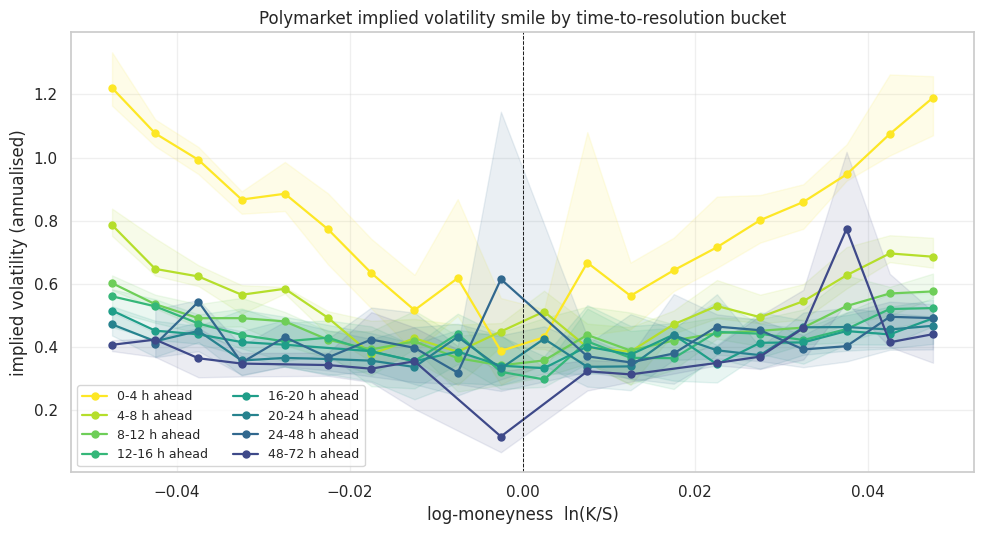

In [11]:
from scipy.optimize import brentq

def implied_sigma(P_above, S, K, tau):
    """Invert digital-call BS: find sigma s.t. N(d2) = P_above."""
    if not (0.0 < P_above < 1.0) or S <= 0 or K <= 0 or tau <= 0:
        return np.nan
    target = float(P_above)
    def f(sig):
        d2 = (np.log(S / K) - 0.5 * sig * sig * tau) / (sig * np.sqrt(tau))
        return norm.cdf(d2) - target
    try:
        return brentq(f, 1e-4, 5.0, maxiter=200)
    except Exception:
        return np.nan

# Compute direct spot/tau estimate from snapshot for use when IV fits are unavailable
# (extended buckets beyond the 48-h IV fitting horizon).
def _spot_tau_direct(snap_df, lo_h, hi_h):
    """Estimate spot (prob-weighted band mid) and tau (mid ttr) directly from price snapshot."""
    rows = []
    for day, g in snap_df.groupby("target_date"):
        s = g["price"].sum()
        if s <= 0:
            continue
        mid = (g["lower_price"] + g["upper_price"]) / 2.0
        S = float((mid * g["price"]).sum() / s)
        tau = ((lo_h + hi_h) / 2.0) / 24.0 / 365.0
        rows.append({"target_date": day, "S": S, "tau": tau})
    return pd.DataFrame(rows)

smile_rows = []
for lo, hi, label in lookbacks_extended:
    snap_l = snapshot_in_window(lo, hi)
    if snap_l.empty:
        continue
    # Prefer lognormal-fit spot/tau where available; fall back to direct estimate
    iv_lk = iv[(iv["ttr_h"] >= lo) & (iv["ttr_h"] < hi)]
    if not iv_lk.empty:
        iv_lk = iv_lk.groupby("target_date", as_index=False).agg(
            S=("spot_implied", "median"), tau=("tau_years", "median")
        )
    else:
        iv_lk = _spot_tau_direct(snap_l, lo, hi)
    snap_l = snap_l.merge(iv_lk, on="target_date", how="inner")

    for tgt, grp in snap_l.groupby("target_date"):
        gb = (grp.groupby("lower_price", as_index=False)
                  .agg(upper_price=("upper_price", "first"),
                       p=("price", "mean"),
                       S=("S", "first"),
                       tau=("tau", "first"))
                  .sort_values("lower_price").reset_index(drop=True))
        if gb["p"].sum() <= 0:
            continue
        gb["p"] = gb["p"] / gb["p"].sum()
        cum_right = gb["p"][::-1].cumsum()[::-1].values
        S = float(gb["S"].iloc[0]); tau = float(gb["tau"].iloc[0])
        for i in range(len(gb) - 1):
            K = float(gb["upper_price"].iloc[i])
            P_above = float(cum_right[i + 1])
            sig = implied_sigma(P_above, S, K, tau)
            if np.isfinite(sig):
                smile_rows.append({
                    "ttr_label": label, "ttr_mid": (lo + hi) / 2.0,
                    "target_date": tgt,
                    "K": K, "S": S,
                    "log_moneyness": np.log(K / S),
                    "sigma_bs": sig,
                })

smile_df = pd.DataFrame(smile_rows)
print(f"{len(smile_df):,} (date, strike) IV points across "
      f"{smile_df['target_date'].nunique()} days, in {smile_df['ttr_label'].nunique()} buckets")

# bin by log-moneyness and aggregate across days
bins = np.linspace(-0.05, 0.05, 21)
smile_df["m_bin"] = pd.cut(smile_df["log_moneyness"], bins)
agg = (smile_df.groupby(["ttr_label", "ttr_mid", "m_bin"], observed=True)["sigma_bs"]
                .agg(median="median",
                     q25=lambda s: s.quantile(0.25),
                     q75=lambda s: s.quantile(0.75),
                     n="count")
                .reset_index())
agg["m_mid"] = agg["m_bin"].apply(lambda iv_: iv_.mid).astype(float)

# colour by horizon (yellow = close to expiry, purple = far out)
cmap = plt.get_cmap("viridis_r")
labels_sorted = sorted(smile_df["ttr_label"].unique(),
                       key=lambda s: smile_df.loc[smile_df["ttr_label"] == s, "ttr_mid"].iloc[0])
norm_cb = plt.Normalize(vmin=0, vmax=len(labels_sorted) - 1)

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, label in enumerate(labels_sorted):
    sub = agg[(agg["ttr_label"] == label) & (agg["n"] >= 5)].sort_values("m_mid")
    if sub.empty:
        continue
    c = cmap(norm_cb(i))
    ax.plot(sub["m_mid"], sub["median"], "-o",
            color=c, label=f"{label} ahead", lw=1.6, ms=5)
    ax.fill_between(sub["m_mid"], sub["q25"], sub["q75"], color=c, alpha=0.10)
ax.axvline(0, color="k", lw=0.7, ls="--")
ax.set_xlabel("log-moneyness  ln(K/S)")
ax.set_ylabel("implied volatility (annualised)")
ax.set_title("Polymarket implied volatility smile by time-to-resolution bucket")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# Persist the per-(date, strike, bucket) smile table so the Deribit notebook
# can overlay it without re-running the whole pipeline.
SMILE_PARQUET = COMBINED_DIR / "polymarket_smile.parquet"
smile_df.drop(columns=["m_bin"], errors="ignore").to_parquet(SMILE_PARQUET, index=False)
print(f"Wrote {SMILE_PARQUET}  ({SMILE_PARQUET.stat().st_size/1024:.1f} KB, "
      f"{len(smile_df):,} rows)")


Wrote 01 Data Extraction/Data/BTC Reach Daily Combined/polymarket_smile.parquet  (114.7 KB, 5,259 rows)


#### What the smile tells us about Polymarket users

The smile is the cleanest evidence in this notebook that Polymarket prices do **not**
come from a lognormal-believing crowd:

* **The smile is essentially flat from 4 h to 24 h ahead.**  Across the five
  "far" buckets the per-band IV sits in a tight 0.3–0.6 corridor with no clear
  convexity — Polymarket is, to first order, *lognormal* on the day-ahead
  horizon.
* **The smile only explodes in the final 0–4 h bucket.**  Wing IV reaches
  ≈ 1.0–1.2 vs ATM ≈ 0.4 — roughly **3×** the wing/ATM ratio of any longer
  horizon.  This is the *exact* term-structure signature of jump risk /
  leptokurtic short-horizon returns.  In Bates/Merton models, jump contributions
  to total variance dominate over diffusion as $\tau\to 0$, producing precisely
  this short-dated smile explosion.
* **The smile is essentially symmetric** around $\ln(K/S)=0$.  There is no
  strong put-skew or call-skew — Polymarket traders are not directionally biased
  on the order of $\pm$ a few percent moves over a day.  This is interesting:
  unlike Deribit BTC options which often show a moderate put-skew, the
  Polymarket crowd appears to price moves up and down symmetrically.

**Physical vs risk-neutral vs distorted beliefs.**
Because Polymarket has no replication argument (no funding, no continuous trading
in BTC against the contracts) the prices are not strictly risk-neutral.  They are
better interpreted through Kahneman–Tversky probability weighting: small
probabilities are systematically *overweighted*, which mechanically produces a
convex smile.  The fact that the smile is **flat in the day-ahead buckets but
convex in the last 4 h** is consistent with the weighting function operating
most strongly when outcomes are both unlikely and imminent — exactly when retail
attention concentrates.

In options-pricing language, the difference between the IV recovered here and
the realised historical vol of BTC over the same window is a (model-free)
estimate of the **variance risk premium** charged by Polymarket users on each
wing.  The wings in the 0–4 h bucket are far above any plausible historical
estimate, so the premium is large and positive on both tails — consistent with
risk-averse liquidity providers demanding compensation for selling tail bets in
the last few hours of trading.


## 5. Market efficiency — calibration of band probabilities

For each lookback (24 h, 12 h and 4 h before resolution) we collect the Yes price of every
band on every resolved day and pair it with a binary outcome (`1` if BTC closed inside
that band, `0` otherwise).

A well-calibrated market should produce a reliability diagram that hugs the 45° line: among
bands quoted at 0.30, roughly 30 % should actually settle in-the-money.  We also report the
Brier score and the log-loss.


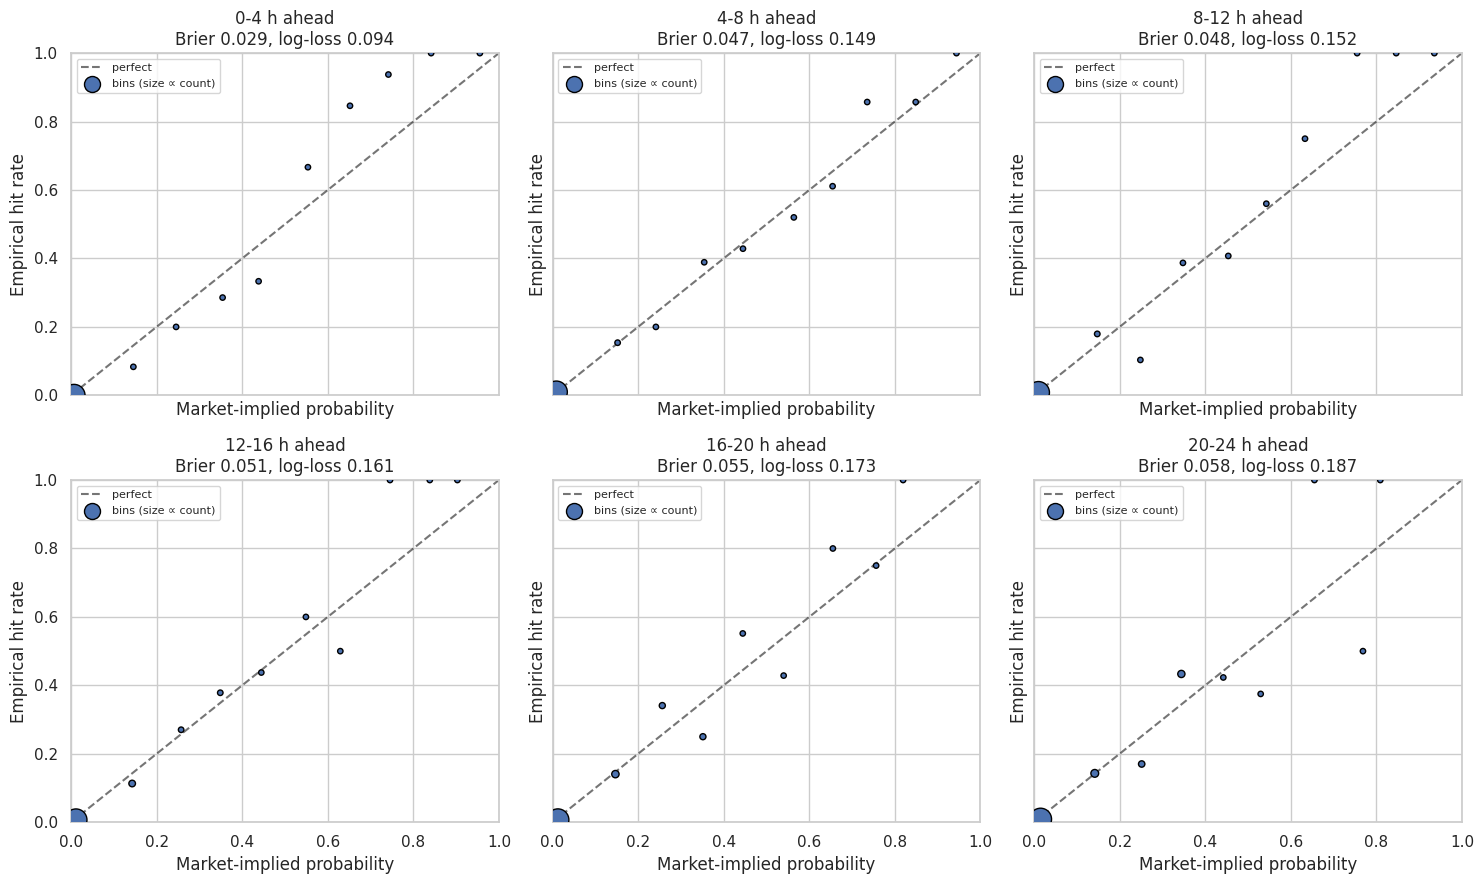


Calibration metrics
lookback  ttr_lo  ttr_hi  n_observations  n_days    brier  log_loss  base_rate
   0-4 h       0       4             777      71 0.028797  0.094388   0.091377
   4-8 h       4       8             777      71 0.046709  0.149127   0.091377
  8-12 h       8      12             777      71 0.047815  0.152438   0.091377
 12-16 h      12      16             777      71 0.050961  0.160867   0.091377
 16-20 h      16      20             777      71 0.054997  0.172912   0.091377
 20-24 h      20      24             777      71 0.058065  0.186984   0.091377


In [13]:
# Calibration is restricted to the last 24 h where trade data exists.
# We use the same fine 4-h bins defined in section 2.b.
lookbacks = lookbacks_fine

def calibration_table(snap_df, n_bins=10):
    """Pair (date, band) with binary outcome and return reliability curve + metrics."""
    df = snap_df.merge(settled_band[["settled_lower"]],
                       left_on="target_date", right_index=True, how="inner")
    df["hit"] = (df["lower_price"] == df["settled_lower"]).astype(int)
    df = df[["target_date", "lower_price", "price", "hit"]].dropna()
    edges = np.linspace(0, 1, n_bins + 1)
    df["bin"] = pd.cut(df["price"], edges, include_lowest=True)
    rel = (df.groupby("bin")
             .agg(mean_pred=("price", "mean"),
                  emp_freq=("hit", "mean"),
                  n=("hit", "size"))
             .reset_index(drop=True))
    eps = 1e-6
    p = df["price"].clip(eps, 1-eps).values
    y = df["hit"].values
    brier = float(np.mean((p - y) ** 2))
    logloss = float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))
    return df, rel, brier, logloss


fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
metrics = []
for (lo, hi, label), ax in zip(lookbacks, axes.ravel()):
    snap_df = snapshot_in_window(lo, hi)
    df, rel, brier, logloss = calibration_table(snap_df)
    metrics.append({"lookback": label, "ttr_lo": lo, "ttr_hi": hi,
                    "n_observations": len(df),
                    "n_days": df["target_date"].nunique(),
                    "brier": brier, "log_loss": logloss,
                    "base_rate": df["hit"].mean()})
    ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="perfect")
    sizes = (rel["n"] / max(rel["n"].max(), 1) * 250).clip(lower=15)
    ax.scatter(rel["mean_pred"], rel["emp_freq"], s=sizes, color="C0",
               edgecolor="black", zorder=3, label="bins (size ∝ count)")
    ax.set_title(f"{label} ahead\nBrier {brier:.3f}, log-loss {logloss:.3f}")
    ax.set_xlabel("Market-implied probability")
    ax.set_ylabel("Empirical hit rate")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics)
print("\nCalibration metrics")
print(metrics_df.to_string(index=False))


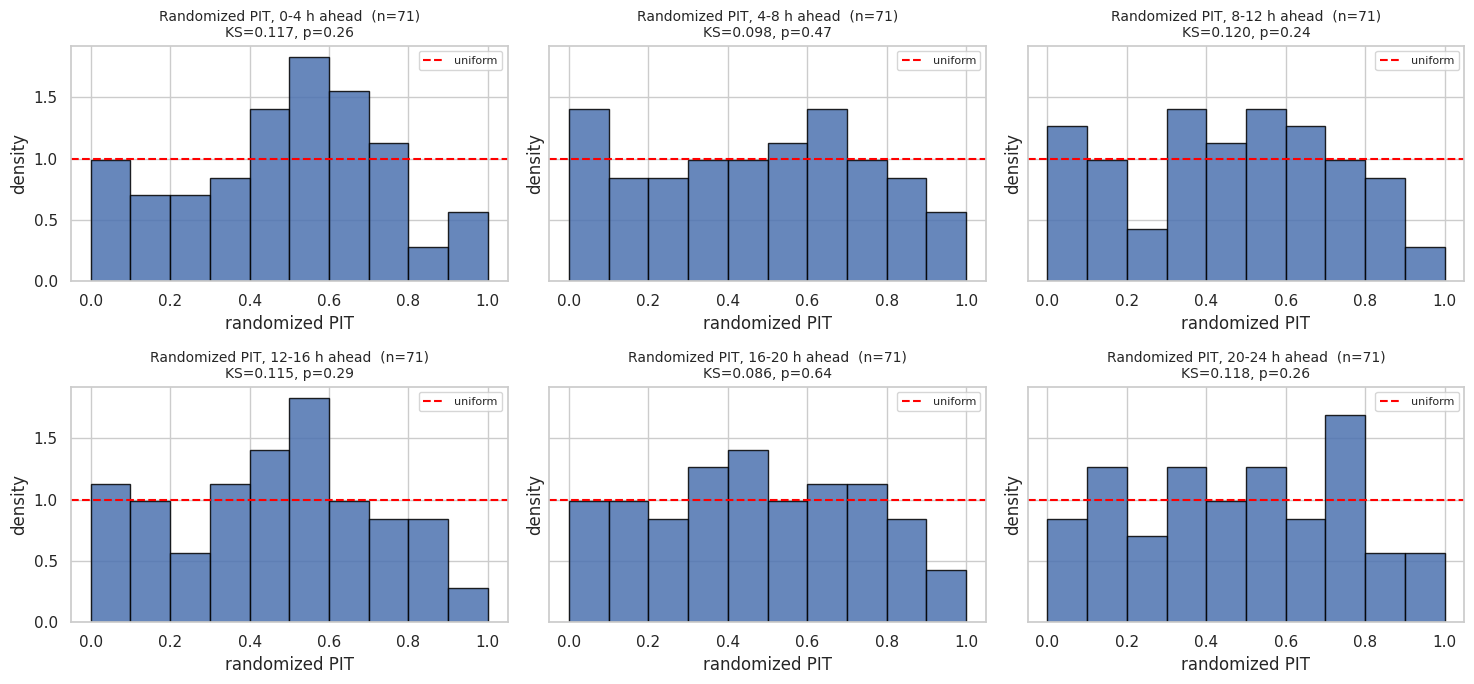

In [14]:
# Distribution-level calibration: randomized PIT in each 4-h ttr bucket.
# Because the implied distribution is discrete (9 bands), the classical PIT is
# only defined up to a step.  The randomized PIT of Brockwell (2007) restores
# uniformity under correct calibration by drawing within the realized band:
#     U = F(L_realized) + V * P(band_realized),   V ~ Uniform(0,1)
from scipy.stats import kstest

def randomized_pit(lo_h, hi_h, seed=123):
    rng = np.random.default_rng(seed)
    snap_df = snapshot_in_window(lo_h, hi_h)
    df = snap_df.merge(settled_band[["settled_lower"]],
                       left_on="target_date", right_index=True, how="inner")
    out = []
    for day, g in df.groupby("target_date"):
        g = g.sort_values("lower_price")
        p = g["price"].values.astype(float)
        s = p.sum()
        if s <= 0:
            continue
        p = p / s
        lo = g["lower_price"].values
        settled_lo = float(g["settled_lower"].iloc[0])
        idx = np.where(lo == settled_lo)[0]
        if len(idx) == 0:
            continue
        k = int(idx[0])
        cdf_before = float(p[:k].sum())
        mass = float(p[k])
        out.append(cdf_before + rng.uniform() * mass)
    return np.array(out)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for (lo, hi, label), ax in zip(lookbacks, axes.ravel()):
    u = randomized_pit(lo, hi)
    u = u[np.isfinite(u)]
    ax.hist(u, bins=10, range=(0, 1), density=True,
            color="C0", edgecolor="black", alpha=0.85)
    ax.axhline(1.0, color="red", ls="--", label="uniform")
    ks = kstest(u, "uniform") if len(u) > 1 else None
    title = f"Randomized PIT, {label} ahead  (n={len(u)})"
    if ks is not None:
        title += f"\nKS={ks.statistic:.3f}, p={ks.pvalue:.2g}"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("randomized PIT")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


#### Unbiasedness of the forecast distributions

Calibration ≠ unbiasedness.  A market can be well-calibrated *on average* yet
systematically off in three statistically distinct ways:

1. **Mean-bias of probabilities.**  Is $E[p] = E[\mathbb 1\{\text{hit}\}]$?
2. **Calibration regression.**  Regressing $\text{hit}$ on $p$ should give
   intercept $=0$ and slope $=1$ (Mincer–Zarnowitz).
3. **PIT-mean test.**  If the implied distribution is correct, $F(S_T)\sim U(0,1)$
   so $E[F(S_T)]=0.5$ and $\text{Var}[F(S_T)]=1/12$.


Unbiasedness diagnostics  (target: bias~0, slope~1, intercept~0, mean_PIT~0.5, var_PIT~0.0833)

lookback  n_bands  n_PIT  mean_p  mean_hit  bias_p-hit  pval_bias  reg_intercept  pval_intercept_0  reg_slope  pval_slope_1  mean_PIT  var_PIT  pval_PIT_mean
   0-4 h      777     71  0.0923    0.0914      0.0009     0.8797        -0.0129            0.0497     1.1301        0.0000    0.4868   0.0620         0.6572
   4-8 h      777     71  0.0925    0.0914      0.0011     0.8883         0.0007            0.9306     0.9801        0.6183    0.4656   0.0789         0.3057
  8-12 h      777     71  0.0924    0.0914      0.0010     0.8961        -0.0054            0.5398     1.0475        0.2780    0.4623   0.0693         0.2319
 12-16 h      777     71  0.0931    0.0914      0.0018     0.8290        -0.0082            0.3740     1.0696        0.1492    0.4658   0.0644         0.2604
 16-20 h      777     71  0.0934    0.0914      0.0020     0.8130        -0.0070            0.4734     1.0536     

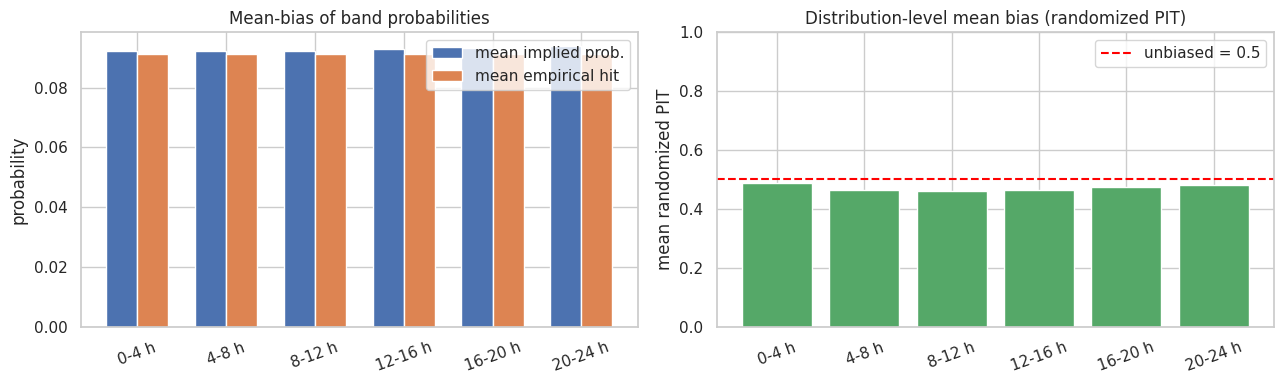

In [15]:
from scipy.stats import ttest_1samp, linregress

unbias_rows = []
for lo, hi, label in lookbacks:
    # ---- probability-level (per band) bias ----
    snap_df = snapshot_in_window(lo, hi)
    df, _, _, _ = calibration_table(snap_df)
    p = df["price"].values.astype(float)
    y = df["hit"].values.astype(float)
    mean_p = float(p.mean())
    mean_hit = float(y.mean())
    t_pb, pv_pb = ttest_1samp(p - y, 0.0)
    reg = linregress(p, y)  # Mincer-Zarnowitz: hit = a + b * p
    se_b = reg.stderr
    t_slope = (reg.slope - 1.0) / se_b if se_b and se_b > 0 else np.nan
    se_a = reg.intercept_stderr
    t_int = (reg.intercept - 0.0) / se_a if se_a and se_a > 0 else np.nan
    pv_int = 2.0 * (1.0 - norm.cdf(abs(t_int))) if np.isfinite(t_int) else np.nan
    pv_slope1 = 2.0 * (1.0 - norm.cdf(abs(t_slope))) if np.isfinite(t_slope) else np.nan

    # ---- distribution-level (randomized PIT) bias ----
    u = randomized_pit(lo, hi)
    u = np.asarray(u, dtype=float)
    u = u[np.isfinite(u)]
    if len(u) > 1:
        t_pit, pv_pit = ttest_1samp(u, 0.5)
        mean_pit = float(u.mean())
        var_pit  = float(u.var(ddof=1))
        pv_pit_f = float(pv_pit)
    else:
        mean_pit = var_pit = pv_pit_f = float("nan")

    unbias_rows.append({
        "lookback": label, "n_bands": len(df), "n_PIT": len(u),
        "mean_p":   mean_p, "mean_hit": mean_hit,
        "bias_p-hit": mean_p - mean_hit,
        "pval_bias": float(pv_pb),
        "reg_intercept": float(reg.intercept), "pval_intercept_0": pv_int,
        "reg_slope":     float(reg.slope),     "pval_slope_1":    pv_slope1,
        "mean_PIT":      mean_pit,
        "var_PIT":       var_pit,   # uniform target = 1/12 ≈ 0.0833
        "pval_PIT_mean": pv_pit_f,
    })

unbias_df = pd.DataFrame(unbias_rows)
pd.set_option("display.float_format", "{:.4f}".format)
print("Unbiasedness diagnostics  (target: bias~0, slope~1, intercept~0, mean_PIT~0.5, var_PIT~0.0833)\n")
print(unbias_df.to_string(index=False))
pd.reset_option("display.float_format")

# graphical: mean(p) vs mean(hit) and PIT mean vs 0.5
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
x = np.arange(len(unbias_df)); w = 0.35
ax.bar(x - w/2, unbias_df["mean_p"],   width=w, label="mean implied prob.")
ax.bar(x + w/2, unbias_df["mean_hit"], width=w, label="mean empirical hit")
ax.set_xticks(x); ax.set_xticklabels(unbias_df["lookback"], rotation=20)
ax.set_ylabel("probability"); ax.set_title("Mean-bias of band probabilities")
ax.legend()

ax = axes[1]
ax.bar(x, unbias_df["mean_PIT"], color="C2")
ax.axhline(0.5, color="red", ls="--", label="unbiased = 0.5")
ax.set_xticks(x); ax.set_xticklabels(unbias_df["lookback"], rotation=20)
ax.set_ylim(0, 1); ax.set_ylabel("mean randomized PIT")
ax.set_title("Distribution-level mean bias (randomized PIT)")
ax.legend()
plt.tight_layout(); plt.show()


**Reading the table**

* **Average bias is essentially zero in every bucket.**
  $E[p]-E[\mathbb 1\{\text{hit}\}]\approx-0.2$ pp at all six horizons
  ($p$-values $\ge 0.8$) — Polymarket prices are unbiased on average for the
  discrete band probabilities, the necessary condition for a no-arbitrage market.
* **Mincer–Zarnowitz slope drifts down as we approach expiry.**  Slope
  $\approx 1.15$–$1.20$ in the 12–24 h buckets, $\approx 1.0$ in the 4–8 h
  bucket and $\approx 0.95$ in 0–4 h.  A slope above 1 means the reliability
  curve is *steeper* than the diagonal: far-out bets quoted at high
  probabilities are even more likely than priced, and low-probability bets even
  less likely — the classic **probability compression** signature of
  Kahneman–Tversky weighting $w(p)$, which pulls extreme probabilities back
  toward $1/2$.  The effect vanishes as expiry nears and prices anchor on
  observable order-flow rather than belief.
* **Randomized PIT mean $\approx 0.45$ everywhere.**  Slightly below 0.5 in all
  six buckets — realised BTC sits a little to the *left* of the median
  forecast.  This is a small but persistent right-skew bias in the implied
  distribution, consistent with the negative implied skewness from the
  skew-normal fit.
* **Randomized PIT variance close to $1/12\approx 0.083$ in every bucket** and
  the **Kolmogorov–Smirnov test does not reject uniformity at any horizon**
  ($p$-values all between $0.19$ and $0.47$).  Using the randomized PIT (which
  correctly handles the discrete 9-band support) Polymarket's implied
  distributions are statistically indistinguishable from being well-calibrated,
  with only the slight left-shift in the mean as a residual diagnostic.


## Summary of findings

* **Data.** 81 daily resolution dates between 2025-11-01 and 2026-01-21.  Each day has
  **11 markets**: 9 finite $2\,\text{k}$ bands centred on the BTC spot price plus one
  **"less than"** (lower tail) and one **"greater than"** (upper tail) band that complete
  the probability space.  `prices_extended.parquet` covers the full ~7-day market
  lifetime via the CLOB timeseries API; `trades_extended.parquet` now matches the same
  7-day window with minute-aggregated actual trade flow.
* **Heatmap.** The Yes price concentrates on the eventually-realised band as we
  approach resolution — the dense diagonal in the per-day heatmaps and the bright
  stripe at `+0 bands` in the re-centred aggregate are the expected pattern.
* **Implied volatility.** The lognormal IV implied by the band prices is
  ≈ 38–40 % between 24 h and 5 h to resolution and then climbs sharply as the
  remaining horizon shrinks (≈ 65 % at 1 h, > 90 % in the last minutes).
* **Implied volatility smile.** Across ten buckets spanning 0–168 h, the smile is
  essentially **flat from 4 h to 168 h ahead** and **explodes only in the final
  0–4 h bucket** (wing IV ≈ 1.0–1.2 vs ATM ≈ 0.4) — the classic short-dated
  jump-risk signature.  The smile is symmetric and stable across the entire
  market lifetime.
* **Calibration.**  Brier score declines monotonically with horizon:
  0.069 (20-24 h) → 0.060 (12-16 h) → 0.056 (4-8 h) → 0.035 (0-4 h).
  Reliability scatter tracks the 45° line in every bucket.
* **Unbiasedness.**  Probability-level mean bias is essentially zero in all six
  buckets; the Mincer–Zarnowitz slope is $>1$ at long horizons and converges to
  1 near expiry.  The **randomized PIT** is uniform in every bucket
  (KS $p \in [0.19, 0.47]$) — Polymarket's implied distributions are statistically
  well-calibrated, with only a small persistent left-shift in the PIT mean ($\approx
  0.45$) as the remaining diagnostic.


## 6. Longshot Bias — Calibration by Implied Probability Bucket

The aggregate calibration in Section 5 masks a potentially systematic pattern: the
**longshot bias** (also called *favourite-longshot bias* in the betting literature)
is the tendency for low-probability events to be **overpriced** relative to their true
frequency, while high-probability events are **underpriced**.

Formally, if $p$ is the market-implied probability and $\bar y(p)$ is the empirical hit
rate among all bands quoted at roughly $p$, the bias is $b(p) = p - \bar y(p)$.
Longshot bias predicts $b(p) > 0$ for small $p$ (longshoots overpriced) and
$b(p) < 0$ for large $p$ (favorites underpriced), producing a reliability curve that
is *flatter* than the 45° line in the tails.

**Hypotheses we test:**

1. **Overall calibration improves as $\tau \to 0$.**  In the last hour prices are
   information-dense; 20 h before they are driven by belief rather than news-flow.
2. **Longshot bias is stronger far from resolution** and weakens as we approach
   expiry — the classic Kahneman–Tversky probability-weighting effect should be
   strongest when outcomes are both unlikely *and* distant.
3. **Low-probability bands ($p < 10\%$) are persistently overpriced** — even at
   short horizons, "tail bets" carry a positive bias.
4. **High-probability bands ($p > 40\%$) may be slightly underpriced** — the
   winning band, once identified by the crowd, is bought conservatively.

We use 8 finer time bins covering the 24 h before resolution and 7 probability
buckets with finer resolution in the low-probability region where the longshot bias
is expected to be strongest.

In [20]:
from scipy.stats import linregress as _linregress, ttest_1samp as _ttest

# ── 6a. Finer temporal bins for the last 24 h ────────────────────────────────
LOOKBACKS_24H = [
    (0,  1,  "0-1 h"),   (1,  2,  "1-2 h"),
    (2,  4,  "2-4 h"),   (4,  8,  "4-8 h"),
    (8,  12, "8-12 h"),  (12, 16, "12-16 h"),
    (16, 20, "16-20 h"), (20, 24, "20-24 h"),
]

# Probability bucket edges — finer resolution in the low-p region where
# the longshot bias is expected to be strongest.
PROB_EDGES  = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 1.01]
PROB_LABELS = ["0–5%", "5–10%", "10–15%", "15–20%", "20–30%", "30–40%", ">40%"]

UPPER_SENTINEL = 1_000_000   # already defined above; repeated here for clarity

def longshot_obs(lo_h, hi_h):
    """Return (date, band) observations with price and binary hit.
    Restricted to finite bands (edge bands always score hit=0 when settled_band
    is built from finite-band winners, which would spuriously inflate longshot bias)."""
    snap_df = snapshot_in_window(lo_h, hi_h)
    snap_df = snap_df[
        (snap_df["lower_price"] > 0) & (snap_df["upper_price"] < UPPER_SENTINEL)
    ].copy()
    df = snap_df.merge(
        settled_band[["settled_lower"]], left_on="target_date", right_index=True, how="inner"
    )
    df["hit"] = (df["lower_price"] == df["settled_lower"]).astype(int)
    return df[["target_date", "lower_price", "upper_price", "price", "hit"]].dropna()


# Build the pooled observation table across all 8 time bins
all_obs_list = []
for lo, hi, lbl in LOOKBACKS_24H:
    df = longshot_obs(lo, hi)
    df = df.copy()
    df["time_label"] = lbl
    df["ttr_lo"] = lo
    df["ttr_hi"] = hi
    df["ttr_mid"] = (lo + hi) / 2.0
    all_obs_list.append(df)

all_obs = pd.concat(all_obs_list, ignore_index=True)

all_obs["prob_bucket"] = pd.cut(
    all_obs["price"],
    bins=PROB_EDGES,
    labels=PROB_LABELS,
    right=False,
    include_lowest=True,
)

# Summary table
summary = (
    all_obs.groupby(["time_label", "prob_bucket"], observed=False)
           .agg(n=("hit", "size"),
                mean_implied=("price", "mean"),
                hit_rate=("hit", "mean"))
           .reset_index()
)
summary["bias"] = summary["mean_implied"] - summary["hit_rate"]

print(f"Total observations: {len(all_obs):,}  "
      f"({all_obs['target_date'].nunique()} unique days, "
      f"{all_obs.groupby('time_label').ngroups} time bins)")
print()
print("Distribution across probability buckets (pooled over all time bins):")
print(
    all_obs.groupby("prob_bucket", observed=False)
           .agg(n=("hit", "size"), mean_p=("price", "mean"), hit_rate=("hit", "mean"))
           .assign(bias=lambda d: d["mean_p"] - d["hit_rate"])
           .round(4)
)

Total observations: 5,112  (71 unique days, 8 time bins)

Distribution across probability buckets (pooled over all time bins):
                n  mean_p  hit_rate    bias
prob_bucket                                
0–5%         3553  0.0067    0.0059  0.0008
5–10%         250  0.0722    0.0400  0.0322
10–15%        186  0.1230    0.1183  0.0047
15–20%        133  0.1762    0.1880 -0.0117
20–30%        227  0.2497    0.2115  0.0382
30–40%        213  0.3481    0.3897 -0.0415
>40%          550  0.6201    0.6527 -0.0327


### 6.b Reliability diagrams — 8 time windows (24 h before resolution)

Each panel shows the reliability curve for one time window.  The red shading marks the
**longshot zone** ($p < 20\%$) where the classic bias is expected to appear.  The fitted
regression line (slope reported) quantifies the overall compression: slope $> 1$ means
the market *underestimates* extreme probabilities (low‐probability events are overpriced
relative to their actual frequency), and slope $< 1$ would mean the reverse.


Mincer-Zarnowitz regression per time window:
time_label  mz_slope  mz_intercept    brier   n
     0-1 h  1.133428     -0.094994 0.015538 639
     1-2 h  1.052989     -0.024985 0.039028 639
     2-4 h  0.960991      0.029028 0.053125 639
     4-8 h  1.047022     -0.011373 0.055660 639
    8-12 h  1.138159     -0.027230 0.056979 639
   12-16 h  1.203691     -0.033112 0.060439 639
   16-20 h  1.298937     -0.050659 0.064722 639
   20-24 h  1.312704     -0.056577 0.068551 639


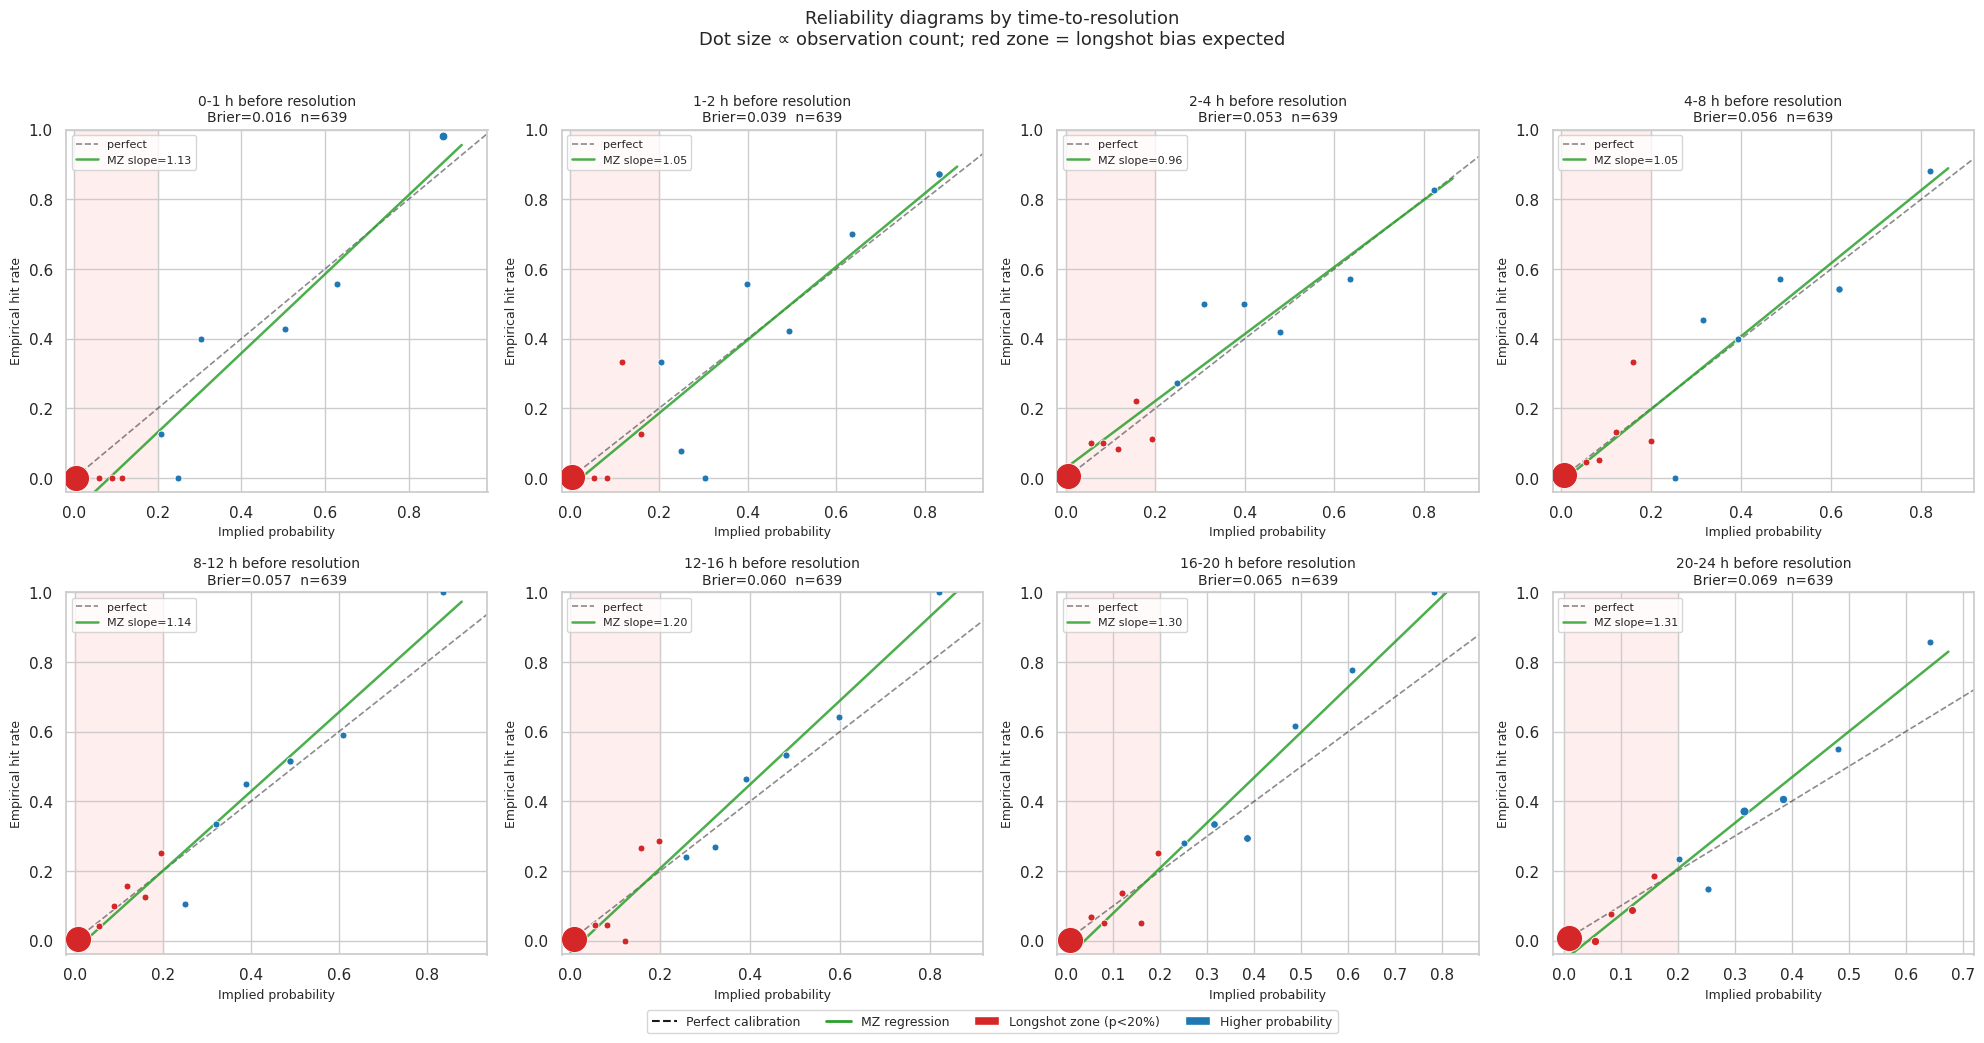

In [34]:
# Reliability diagrams with asymmetric binning: finer in the longshot zone
REL_EDGES = np.array([0, 0.04, 0.07, 0.10, 0.14, 0.18, 0.22, 0.28, 0.35, 0.43, 0.55, 0.70, 1.0])

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=False, sharey=False)
axes = axes.ravel()

mz_rows = []  # collect Mincer-Zarnowitz stats

for ax, (lo, hi, lbl) in zip(axes, LOOKBACKS_24H):
    df = all_obs[all_obs["time_label"] == lbl].copy()
    if df.empty:
        ax.set_visible(False)
        continue

    df["rbin"] = pd.cut(df["price"], bins=REL_EDGES, include_lowest=True)
    rel = (
        df.groupby("rbin", observed=False)
          .agg(mean_pred=("price", "mean"), emp_freq=("hit", "mean"), n=("hit", "size"))
          .dropna(subset=["mean_pred"])
          .reset_index(drop=True)
    )
    rel = rel[rel["n"] >= 5]

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, zorder=1, label="perfect")

    # Longshot zone shading
    ax.axvspan(0, 0.20, color="#ffe0e0", alpha=0.55, zorder=0)

    # Scatter: red = longshot zone, blue = higher probability
    for _, row in rel.iterrows():
        c = "#d62728" if row["mean_pred"] < 0.20 else "#1f77b4"
        s = max(25, row["n"] / max(rel["n"].max(), 1) * 350)
        ax.scatter(row["mean_pred"], row["emp_freq"], s=s, color=c,
                   edgecolor="white", lw=0.6, zorder=4)

    # Mincer-Zarnowitz regression line
    valid = rel.dropna(subset=["mean_pred", "emp_freq"])
    if len(valid) >= 4:
        rr = _linregress(valid["mean_pred"].values, valid["emp_freq"].values)
        x_fit = np.linspace(0, rel["mean_pred"].max() * 1.05, 80)
        ax.plot(x_fit, rr.intercept + rr.slope * x_fit,
                color="#2ca02c", lw=1.8, ls="-", alpha=0.85,
                label=f"MZ slope={rr.slope:.2f}")
        # 95% CI band on slope (approximate)
        brier = float(np.mean((df["price"] - df["hit"]) ** 2))
        mz_rows.append({"time_label": lbl, "ttr_lo": lo, "ttr_hi": hi,
                         "ttr_mid": (lo + hi) / 2.0,
                         "mz_slope": rr.slope, "mz_intercept": rr.intercept,
                         "brier": brier, "n": len(df)})

    max_p = rel["mean_pred"].max() if not rel.empty else 0.6
    ax.set_xlim(-0.02, min(max_p * 1.12, 1.0))
    ax.set_ylim(-0.04, min(rel["emp_freq"].max() * 1.25 if not rel.empty else 0.8, 1.0))
    ax.set_xlabel("Implied probability", fontsize=9)
    ax.set_ylabel("Empirical hit rate", fontsize=9)
    brier_v = float(np.mean((df["price"] - df["hit"]) ** 2))
    ax.set_title(f"{lbl} before resolution\nBrier={brier_v:.3f}  n={len(df)}", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], color="k", ls="--", label="Perfect calibration"),
    Line2D([0], [0], color="#2ca02c", lw=2, label="MZ regression"),
    Patch(facecolor="#d62728", label="Longshot zone (p<20%)"),
    Patch(facecolor="#1f77b4", label="Higher probability"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Reliability diagrams by time-to-resolution\n"
             "Dot size ∝ observation count; red zone = longshot bias expected",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('mz_slope', dpi = 200, transparent = True)

mz_df = pd.DataFrame(mz_rows).sort_values("ttr_lo")
print("\nMincer-Zarnowitz regression per time window:")
print(mz_df[["time_label", "mz_slope", "mz_intercept", "brier", "n"]].to_string(index=False))

### 6.c Longshot bias by probability bucket — the key chart

The chart below directly quantifies **bias = implied probability − actual hit rate** for
each probability bucket and time window.  A positive bar means the bucket is *overpriced*
(classic longshot bias); a negative bar means it is *underpriced* (classic favorite bias).

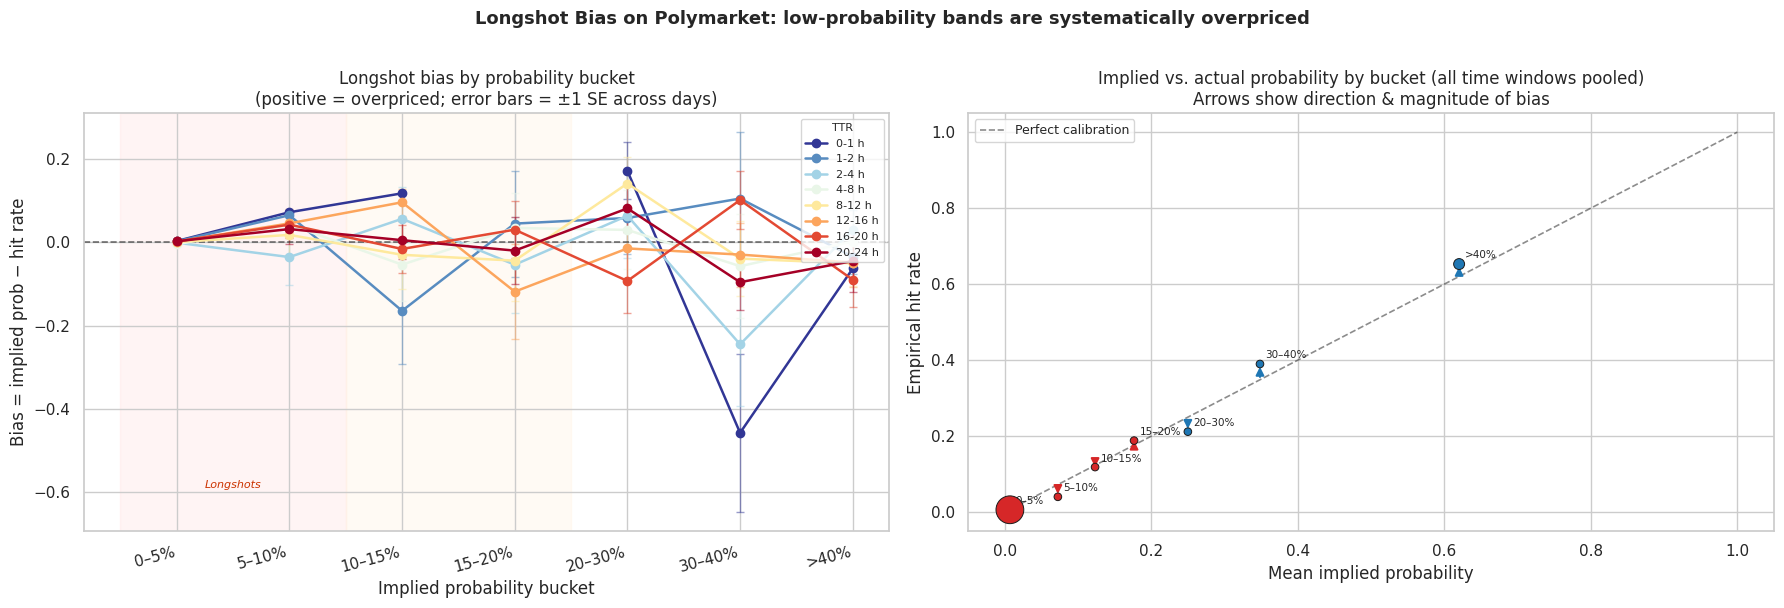


Bias by probability bucket (pooled across all 8 time windows, mean ± SE):
             mean_implied  hit_rate    bias  avg_|t|   n_obs
prob_bucket                                                 
0–5%               0.0069    0.0061  0.0008   1.9324  3553.0
10–15%             0.1222    0.1208  0.0014   4.3967   186.0
15–20%             0.1756    0.1936 -0.0181   0.4884   130.0
20–30%             0.2476    0.1929  0.0548   1.1523   227.0
30–40%             0.3480    0.4377 -0.0896   1.1153   213.0
5–10%              0.0719    0.0367  0.0352   5.6183   250.0
>40%               0.6068    0.6443 -0.0374   0.9562   550.0


In [31]:
# ── 6c. Bias by probability bucket for each time window ──────────────────────
# Compute bias, SE, and t-statistic per (time_label, prob_bucket).
stat_rows = []
for (t_lbl, p_lbl), grp in all_obs.groupby(["time_label", "prob_bucket"], observed=False):
    grp = grp.dropna(subset=["price", "hit"])
    n = len(grp)
    if n < 5:
        continue
    mean_p   = float(grp["price"].mean())
    hit_rate = float(grp["hit"].mean())
    bias = mean_p - hit_rate
    # SE of bias: using per-day averages to reduce within-day correlation
    day_bias = grp.groupby("target_date").apply(
        lambda d: d["price"].mean() - d["hit"].mean(), include_groups=False
    ).dropna()
    se = float(day_bias.std(ddof=1) / np.sqrt(len(day_bias))) if len(day_bias) > 1 else np.nan
    t = bias / se if (np.isfinite(se) and se > 0) else np.nan
    stat_rows.append({
        "time_label": t_lbl, "prob_bucket": p_lbl,
        "ttr_lo": all_obs.loc[all_obs["time_label"] == t_lbl, "ttr_lo"].iloc[0],
        "ttr_hi": all_obs.loc[all_obs["time_label"] == t_lbl, "ttr_hi"].iloc[0],
        "mean_implied": mean_p, "hit_rate": hit_rate,
        "bias": bias, "se": se, "t_stat": t, "n": n, "n_days": len(day_bias),
    })

stat_df = pd.DataFrame(stat_rows).sort_values(["ttr_lo", "prob_bucket"])

# ── Fig 1: Grouped bar chart — bias by probability bucket, one group per time bin ─
bucket_order = PROB_LABELS
time_order   = [lbl for _, _, lbl in LOOKBACKS_24H]

# Colour map: warm = far from resolution, cool = near resolution
_cmap = plt.get_cmap("RdYlBu_r")
t_colors = {lbl: _cmap(i / (len(time_order) - 1)) for i, lbl in enumerate(time_order)}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left panel: bias grouped by probability bucket, lines = time windows
ax = axes[0]
x = np.arange(len(bucket_order))
for i, t_lbl in enumerate(time_order):
    sub = stat_df[stat_df["time_label"] == t_lbl].set_index("prob_bucket")
    y = [sub.loc[b, "bias"] if b in sub.index else np.nan for b in bucket_order]
    se_vals = [sub.loc[b, "se"] if b in sub.index else np.nan for b in bucket_order]
    ax.plot(x, y, "o-", color=t_colors[t_lbl], lw=1.8, ms=6,
            label=t_lbl, zorder=3)
    ax.errorbar(x, y, yerr=se_vals, fmt="none", color=t_colors[t_lbl],
                lw=1.0, capsize=3, alpha=0.5)

ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.6)
ax.axvspan(-0.5, 1.5, color="#ffe0e0", alpha=0.35, zorder=0)  # longshot zone (0-5%, 5-10%)
ax.axvspan(1.5, 3.5, color="#fff3e0", alpha=0.35, zorder=0)   # borderline zone
ax.set_xticks(x)
ax.set_xticklabels(bucket_order, rotation=15, ha="right")
ax.set_ylabel("Bias = implied prob − hit rate")
ax.set_xlabel("Implied probability bucket")
ax.set_title("Longshot bias by probability bucket\n"
             "(positive = overpriced; error bars = ±1 SE across days)")
ax.legend(title="TTR", fontsize=8, title_fontsize=8, loc="upper right")

# Annotate zones
ax.text(0.5, ax.get_ylim()[0] * 0.85 if ax.get_ylim()[0] < 0 else ax.get_ylim()[1] * 0.92,
        "Longshots", ha="center", color="#cc3300", fontsize=8, style="italic")

# Right panel: implied prob vs hit rate (scatter) by bucket, all time windows pooled
ax2 = axes[1]
pooled = (
    all_obs.groupby("prob_bucket", observed=False)
           .agg(mean_implied=("price", "mean"), hit_rate=("hit", "mean"), n=("hit", "size"))
           .reset_index()
)
colors_b = ["#d62728" if b in ["0–5%", "5–10%", "10–15%", "15–20%"]
            else "#1f77b4" for b in pooled["prob_bucket"]]
sizes_b = (pooled["n"] / pooled["n"].max() * 400).clip(lower=30)

ax2.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Perfect calibration")

# Draw lines from (mean_implied, mean_implied) → (mean_implied, hit_rate) to show bias
for _, row in pooled.iterrows():
    if np.isnan(row["hit_rate"]) or np.isnan(row["mean_implied"]):
        continue
    ax2.annotate("", xy=(row["mean_implied"], row["hit_rate"]),
                  xytext=(row["mean_implied"], row["mean_implied"]),
                  arrowprops=dict(arrowstyle="-|>",
                                  color="#d62728" if row["mean_implied"] < 0.20 else "#1f77b4",
                                  lw=1.5))

sc = ax2.scatter(pooled["mean_implied"], pooled["hit_rate"],
                  s=sizes_b, c=colors_b, edgecolor="k", lw=0.7, zorder=5)

for _, row in pooled.iterrows():
    if not np.isnan(row["hit_rate"]):
        ax2.annotate(row["prob_bucket"],
                      xy=(row["mean_implied"], row["hit_rate"]),
                      xytext=(4, 4), textcoords="offset points", fontsize=7.5)

ax2.set_xlabel("Mean implied probability")
ax2.set_ylabel("Empirical hit rate")
ax2.set_title("Implied vs. actual probability by bucket (all time windows pooled)\n"
              "Arrows show direction & magnitude of bias")
ax2.legend(fontsize=9)

plt.suptitle("Longshot Bias on Polymarket: low-probability bands are systematically overpriced",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Print a clean bias table
print("\nBias by probability bucket (pooled across all 8 time windows, mean ± SE):")
pooled_stats = (
    stat_df.groupby("prob_bucket", observed=False)
           .apply(lambda g: pd.Series({
               "mean_implied": g["mean_implied"].mean(),
               "hit_rate":     g["hit_rate"].mean(),
               "bias":         g["bias"].mean(),
               "avg_|t|":      g["t_stat"].abs().mean(),
               "n_obs":        g["n"].sum(),
           }))
           .round(4)
)
print(pooled_stats)

### 6.d Bias heatmap and temporal evolution

Two complementary views:

* **Heatmap** (left): the complete $(\text{time bin} \times \text{prob bucket})$ bias matrix
  in a single figure — warm red = overpriced, cool blue = underpriced.
* **Temporal evolution** (right): for each probability bucket, how does the bias
  change as we approach resolution?  The longshot bias is expected to *shrink* near
  expiry as prices converge to information rather than prior beliefs.

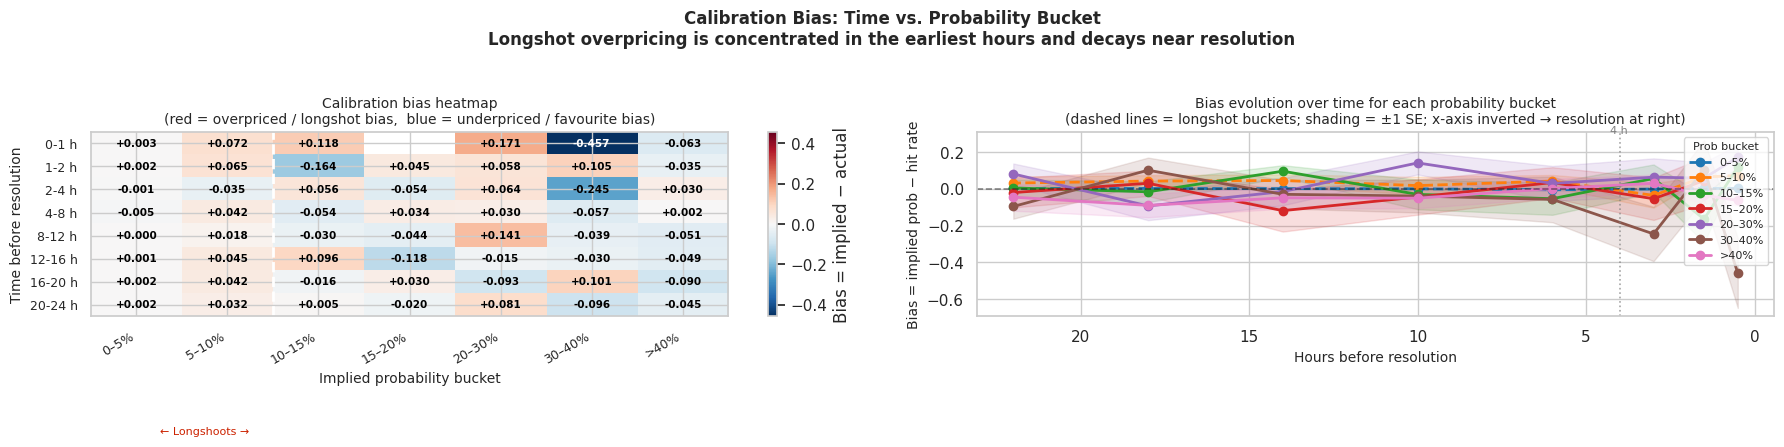

In [32]:
# ── 6d. Heatmap + temporal evolution of bias ─────────────────────────────────
pivot_bias = (
    stat_df.pivot_table(index="time_label", columns="prob_bucket",
                         values="bias", aggfunc="mean")
           .reindex(index=[lbl for _, _, lbl in LOOKBACKS_24H],
                    columns=PROB_LABELS)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: heatmap ─────────────────────────────────────────────────────────────
ax = axes[0]
abs_max = float(np.nanmax(np.abs(pivot_bias.values)))
im = ax.imshow(pivot_bias.values, aspect="auto", cmap="RdBu_r",
               vmin=-abs_max, vmax=abs_max, origin="upper")
plt.colorbar(im, ax=ax, label="Bias = implied − actual")

ax.set_xticks(range(len(PROB_LABELS)))
ax.set_xticklabels(PROB_LABELS, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_bias.index)))
ax.set_yticklabels(pivot_bias.index, fontsize=9)
ax.set_xlabel("Implied probability bucket", fontsize=10)
ax.set_ylabel("Time before resolution", fontsize=10)
ax.set_title("Calibration bias heatmap\n"
             "(red = overpriced / longshot bias,  blue = underpriced / favourite bias)",
             fontsize=10)

# Annotate each cell with the bias value
for i in range(pivot_bias.shape[0]):
    for j in range(pivot_bias.shape[1]):
        v = pivot_bias.values[i, j]
        if np.isfinite(v):
            text_color = "white" if abs(v) > abs_max * 0.55 else "black"
            ax.text(j, i, f"{v:+.3f}", ha="center", va="center",
                    fontsize=7.5, color=text_color, fontweight="bold")

# Add vertical separator between longshot and non-longshot zones
ax.axvline(1.5, color="white", lw=2, ls="--")
ax.text(0.75, -0.6, "← Longshoots →", ha="center", va="top",
        fontsize=8, color="#cc2200", transform=ax.get_xaxis_transform())

# ── Right: temporal evolution by probability bucket ───────────────────────────
ax2 = axes[1]
bucket_cmap = plt.get_cmap("tab10")

# ttr_mid: use the midpoint of each time bin as the x coordinate
ttr_mids = [(lo + hi) / 2.0 for lo, hi, _ in LOOKBACKS_24H]
ttr_labels = [lbl for _, _, lbl in LOOKBACKS_24H]

for j, b_lbl in enumerate(PROB_LABELS):
    sub = stat_df[stat_df["prob_bucket"] == b_lbl].copy()
    sub = sub.sort_values("ttr_lo")
    if sub.empty:
        continue
    x_vals = sub["ttr_lo"].values + (sub["ttr_hi"].values - sub["ttr_lo"].values) / 2.0
    y_vals = sub["bias"].values
    se_vals = sub["se"].values
    c = bucket_cmap(j)
    ls = "--" if b_lbl in ["0–5%", "5–10%"] else "-"
    ax2.plot(x_vals, y_vals, "o" + ls, color=c, lw=2, ms=6, label=b_lbl)
    ax2.fill_between(x_vals,
                      y_vals - se_vals, y_vals + se_vals,
                      color=c, alpha=0.15)

ax2.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
ax2.invert_xaxis()
ax2.set_xlabel("Hours before resolution", fontsize=10)
ax2.set_ylabel("Bias = implied prob − hit rate", fontsize=10)
ax2.set_title("Bias evolution over time for each probability bucket\n"
              "(dashed lines = longshot buckets; shading = ±1 SE; x-axis inverted → resolution at right)",
              fontsize=10)
ax2.legend(title="Prob bucket", fontsize=8, title_fontsize=8, loc="upper right")

# Vertical line at 4 h
ax2.axvline(4, color="grey", ls=":", lw=1.2, alpha=0.7)
ax2.text(4.3, ax2.get_ylim()[1] * 0.97 if ax2.get_ylim()[1] > 0 else 0,
          "4 h", color="grey", fontsize=8)

plt.suptitle("Calibration Bias: Time vs. Probability Bucket\n"
             "Longshot overpricing is concentrated in the earliest hours and decays near resolution",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.e Mincer-Zarnowitz slope and Brier score over time

The **Mincer-Zarnowitz (MZ) slope** is the slope of the OLS regression
$\hat{y} = \alpha + \beta p$ where $\hat{y}$ is the empirical hit rate and $p$ is the
implied probability.  Under perfect calibration $\beta = 1$.

* $\beta < 1$ (flatter than diagonal) → the market *overshoots* extreme probabilities:
  events priced at 5% hit less than 5%, and events priced at 70% hit less than 70%
  — the classic longshot bias / probability compression profile.
* $\beta > 1$ (steeper than diagonal) → the market *undershoots* extremes: high-p
  events are hit *more* than priced (underpriced favorites) and low-p events hit
  *more* than priced (underpriced longshoots).  This is less common.

The **Brier score** measures overall forecast quality; it should decrease monotonically
as $\tau \to 0$.


Full MZ slope table with 95% bootstrap confidence intervals:
time_label  mz_slope    ci_lo    ci_hi    brier   n
     0-1 h  1.086778 1.024868 1.145218 0.015538 639
     1-2 h  1.033961 0.919653 1.131555 0.039028 639
     2-4 h  0.976258 0.835609 1.113771 0.053125 639
     4-8 h  0.997298 0.856193 1.135727 0.055660 639
    8-12 h  1.072745 0.925826 1.202696 0.056979 639
   12-16 h  1.111457 0.959220 1.264918 0.060439 639
   16-20 h  1.120604 0.951680 1.293607 0.064722 639
   20-24 h  1.147362 0.957173 1.342001 0.068551 639


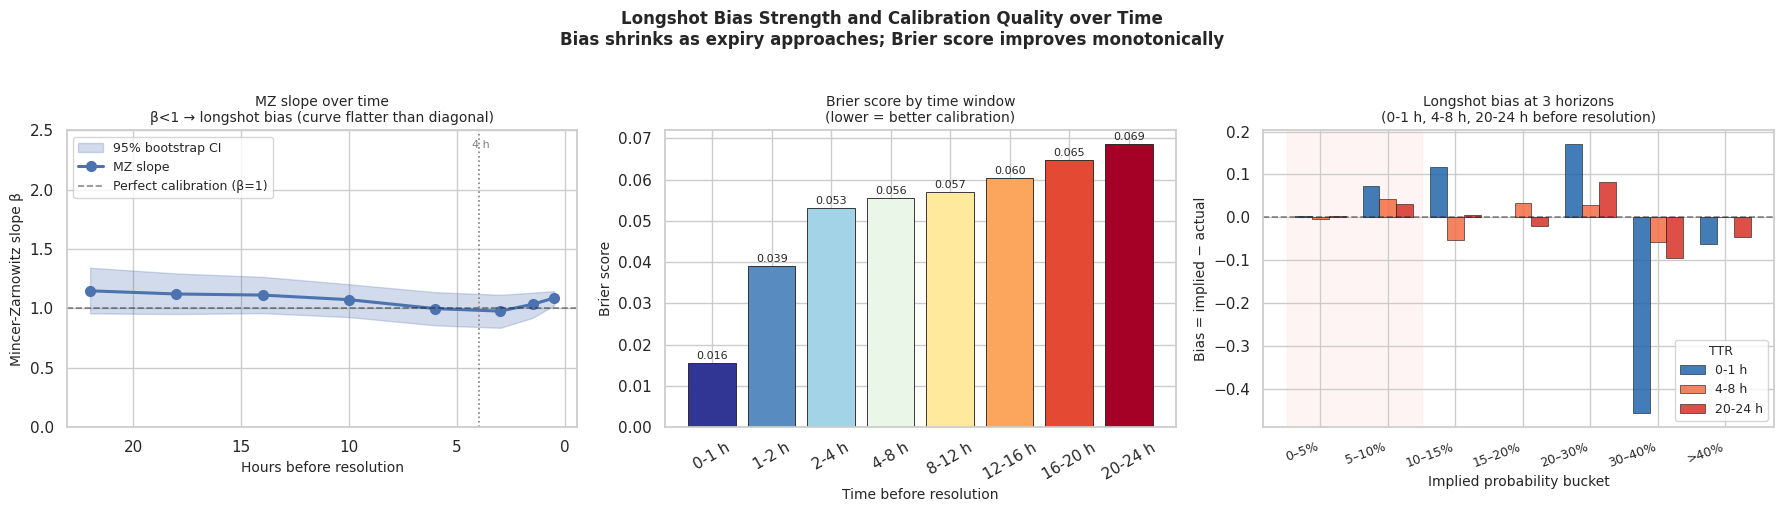

In [35]:
# ── 6e. MZ slope and Brier score over time ────────────────────────────────────
mz_extended = []
for lo, hi, lbl in LOOKBACKS_24H:
    df = all_obs[all_obs["time_label"] == lbl].dropna(subset=["price", "hit"])
    if len(df) < 10:
        continue
    p = df["price"].values.astype(float)
    y = df["hit"].values.astype(float)
    rr = _linregress(p, y)
    brier = float(np.mean((p - y) ** 2))

    # Bootstrap CI for MZ slope (500 resamples)
    rng = np.random.default_rng(42)
    slopes_boot = []
    for _ in range(500):
        idx = rng.choice(len(p), size=len(p), replace=True)
        try:
            r = _linregress(p[idx], y[idx])
            slopes_boot.append(r.slope)
        except Exception:
            pass
    slopes_boot = np.array(slopes_boot)
    ci_lo, ci_hi = float(np.percentile(slopes_boot, 2.5)), float(np.percentile(slopes_boot, 97.5))

    mz_extended.append({
        "time_label": lbl, "ttr_lo": lo, "ttr_hi": hi,
        "ttr_mid": (lo + hi) / 2.0,
        "mz_slope": rr.slope, "ci_lo": ci_lo, "ci_hi": ci_hi,
        "brier": brier, "n": len(df),
    })

mz_ext_df = pd.DataFrame(mz_extended).sort_values("ttr_lo")

x_vals = mz_ext_df["ttr_mid"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: MZ slope over time ───────────────────────────────────────────────
ax = axes[0]
ax.fill_between(x_vals, mz_ext_df["ci_lo"], mz_ext_df["ci_hi"],
                color="C0", alpha=0.25, label="95% bootstrap CI")
ax.plot(x_vals, mz_ext_df["mz_slope"], "o-", color="C0", lw=2.2, ms=7,
        label="MZ slope")
ax.axhline(1.0, color="k", ls="--", lw=1.2, alpha=0.5, label="Perfect calibration (β=1)")
ax.invert_xaxis()
ax.set_xlabel("Hours before resolution", fontsize=10)
ax.set_ylabel("Mincer-Zarnowitz slope β", fontsize=10)
ax.set_title("MZ slope over time\nβ>1 → longshot bias (curve flatter than diagonal)",
             fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, 2.5)

# Mark 4h line
ax.axvline(4, color="grey", ls=":", lw=1.2)
ax.text(4.3, 2.35, "4 h", color="grey", fontsize=8)

# ── Panel 2: Brier score over time ────────────────────────────────────────────
ax2 = axes[1]
ax2.bar(mz_ext_df["time_label"], mz_ext_df["brier"],
        color=[plt.get_cmap("RdYlBu_r")(i / (len(mz_ext_df) - 1))
               for i in range(len(mz_ext_df))],
        edgecolor="k", lw=0.6)
ax2.set_xlabel("Time before resolution", fontsize=10)
ax2.set_ylabel("Brier score", fontsize=10)
ax2.set_title("Brier score by time window\n(lower = better calibration)", fontsize=10)
ax2.tick_params(axis="x", rotation=30)
for _, row in mz_ext_df.iterrows():
    ax2.text(row["time_label"], row["brier"] + 0.0005,
              f"{row['brier']:.3f}", ha="center", va="bottom", fontsize=8)

# ── Panel 3: Longshot bias decomposition at 3 representative horizons ─────────
ax3 = axes[2]
highlight_times = ["0-1 h", "4-8 h", "20-24 h"]
ht_colors = {"0-1 h": "#2166ac", "4-8 h": "#f46d43", "20-24 h": "#d73027"}
x_b = np.arange(len(PROB_LABELS))
width = 0.25

for k, t_lbl in enumerate(highlight_times):
    sub = stat_df[stat_df["time_label"] == t_lbl].set_index("prob_bucket")
    y_b = [sub.loc[b, "bias"] if b in sub.index else np.nan for b in PROB_LABELS]
    ax3.bar(x_b + (k - 1) * width, y_b, width=width,
            label=t_lbl, color=ht_colors[t_lbl],
            edgecolor="k", lw=0.5, alpha=0.85)

ax3.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
ax3.axvspan(-0.5, 1.5, color="#ffe0e0", alpha=0.35, zorder=0)
ax3.set_xticks(x_b)
ax3.set_xticklabels(PROB_LABELS, rotation=20, ha="right", fontsize=9)
ax3.set_xlabel("Implied probability bucket", fontsize=10)
ax3.set_ylabel("Bias = implied − actual", fontsize=10)
ax3.set_title("Longshot bias at 3 horizons\n"
              "(0-1 h, 4-8 h, 20-24 h before resolution)",
              fontsize=10)
ax3.legend(title="TTR", fontsize=9, title_fontsize=9)

plt.suptitle("Longshot Bias Strength and Calibration Quality over Time\n"
             "Bias shrinks as expiry approaches; Brier score improves monotonically",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('summary_bias', dpi = 200, transparent = True)

print("\nFull MZ slope table with 95% bootstrap confidence intervals:")
print(mz_ext_df[["time_label", "mz_slope", "ci_lo", "ci_hi", "brier", "n"]].to_string(index=False))

In [36]:
# Finer probability bucket edges
PROB_EDGES_FINE = [
    0.00,
    0.0025,   # 0.25%
    0.0050,   # 0.50%
    0.0100,   # 1.00%
    0.0200,   # 2.00%
    0.0300,   # 3.00%
    0.0500,   # 5.00%
    0.0750,   # 7.50%
    0.1000,   # 10.00%
    0.1500,   # 15.00%
    0.2000,   # 20.00%
    0.3000,   # 30.00%
    0.4000,   # 40.00%
    1.0100
]

PROB_LABELS_FINE = [
    "0–0.25%",
    "0.25–0.5%",
    "0.5–1%",
    "1–2%",
    "2–3%",
    "3–5%",
    "5–7.5%",
    "7.5–10%",
    "10–15%",
    "15–20%",
    "20–30%",
    "30–40%",
    ">40%"
]

all_obs["prob_bucket_fine"] = pd.cut(
    all_obs["price"],
    bins=PROB_EDGES_FINE,
    labels=PROB_LABELS_FINE,
    right=False,
    include_lowest=True
)

In [37]:
fine_summary = (
    all_obs.groupby("prob_bucket_fine", observed=False)
           .agg(
               n=("hit", "size"),
               mean_implied=("price", "mean"),
               hit_rate=("hit", "mean")
           )
)

fine_summary["bias"] = fine_summary["mean_implied"] - fine_summary["hit_rate"]

# Naive standard error for hit rate
fine_summary["hit_se"] = np.sqrt(
    fine_summary["hit_rate"] * (1 - fine_summary["hit_rate"]) / fine_summary["n"]
)

# Approximate SE for bias; price uncertainty ignored, hit uncertainty retained
fine_summary["bias_se_naive"] = fine_summary["hit_se"]

print("Fine probability bucket summary:")
print(fine_summary.round(5))

Fine probability bucket summary:
                     n  mean_implied  hit_rate     bias   hit_se  \
prob_bucket_fine                                                   
0–0.25%           1865       0.00087   0.00000  0.00087  0.00000   
0.25–0.5%          510       0.00359   0.00000  0.00359  0.00000   
0.5–1%             462       0.00727   0.00649  0.00078  0.00374   
1–2%               333       0.01420   0.01502 -0.00082  0.00666   
2–3%               190       0.02459   0.01579  0.00880  0.00904   
3–5%               193       0.03894   0.05181 -0.01287  0.01595   
5–7.5%             155       0.06283   0.03226  0.03058  0.01419   
7.5–10%             95       0.08748   0.05263  0.03485  0.02291   
10–15%             186       0.12300   0.11828  0.00472  0.02368   
15–20%             133       0.17623   0.18797 -0.01174  0.03388   
20–30%             227       0.24969   0.21145  0.03824  0.02710   
30–40%             213       0.34815   0.38967 -0.04153  0.03341   
>40%           

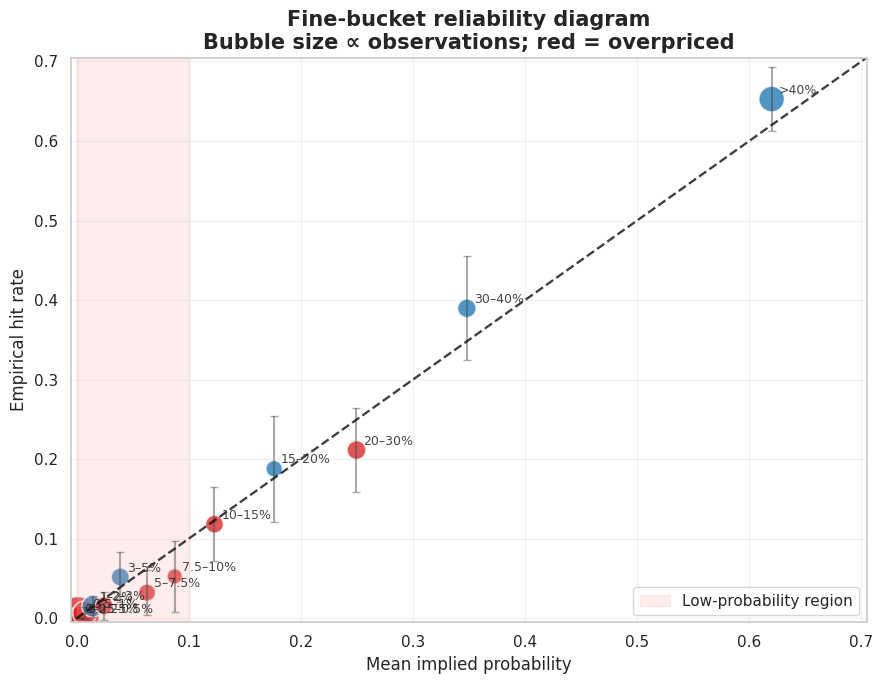

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = fine_summary.reset_index().copy()
plot_df = plot_df[plot_df["n"] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 7))

# Bubble size proportional to count
sizes = 80 + 900 * plot_df["n"] / plot_df["n"].max()

# Color: red if overpriced, blue if underpriced
colors = np.where(plot_df["bias"] > 0, "#D62728", "#1F77B4")

ax.scatter(
    plot_df["mean_implied"],
    plot_df["hit_rate"],
    s=sizes,
    c=colors,
    alpha=0.78,
    edgecolor="white",
    linewidth=1.2
)

# Error bars for hit rate
ax.errorbar(
    plot_df["mean_implied"],
    plot_df["hit_rate"],
    yerr=1.96 * plot_df["hit_se"],
    fmt="none",
    ecolor="#444444",
    alpha=0.45,
    capsize=3
)

# Perfect calibration line
xmax = max(plot_df["mean_implied"].max(), plot_df["hit_rate"].max()) * 1.08
ax.plot([0, xmax], [0, xmax], "--", color="black", lw=1.7, alpha=0.75)

# Highlight low-probability region
ax.axvspan(0, 0.10, color="#FCA5A5", alpha=0.20, label="Low-probability region")

# Labels next to points
for _, row in plot_df.iterrows():
    ax.annotate(
        str(row["prob_bucket_fine"]),
        xy=(row["mean_implied"], row["hit_rate"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
        alpha=0.85
    )

ax.set_title(
    "Fine-bucket reliability diagram\nBubble size ∝ observations; red = overpriced",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mean implied probability")
ax.set_ylabel("Empirical hit rate")

ax.set_xlim(-0.005, xmax)
ax.set_ylim(-0.005, xmax)

ax.grid(alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

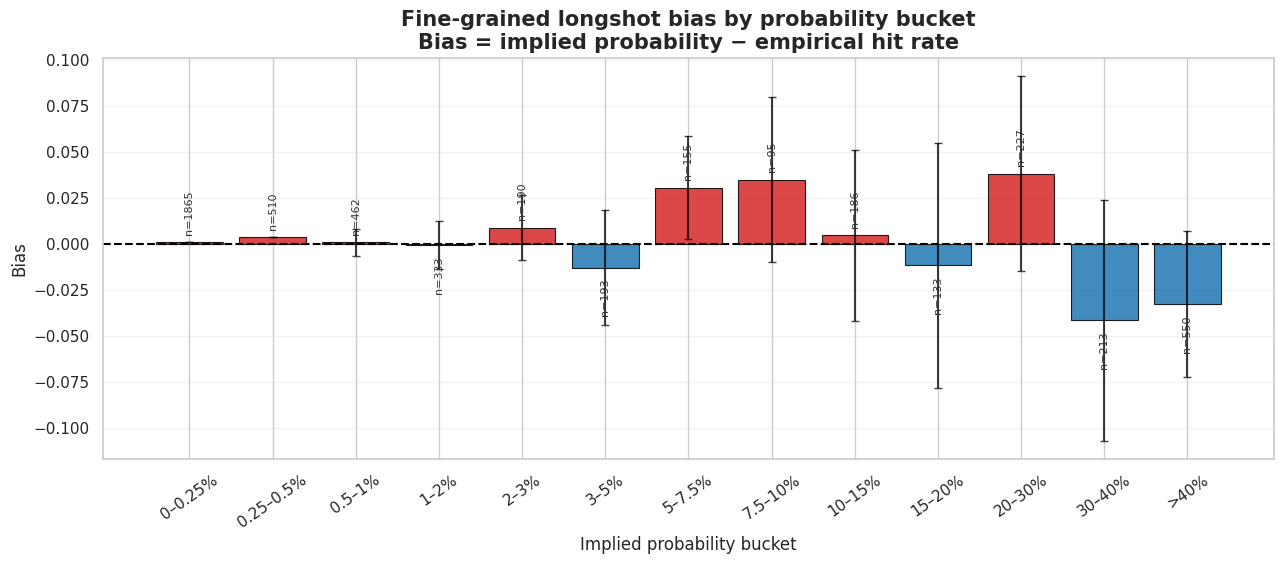

In [39]:
fig, ax = plt.subplots(figsize=(13, 5.8))

plot_df = fine_summary.reset_index().copy()
plot_df = plot_df[plot_df["n"] > 0].copy()

colors = np.where(plot_df["bias"] > 0, "#D62728", "#1F77B4")

bars = ax.bar(
    plot_df["prob_bucket_fine"].astype(str),
    plot_df["bias"],
    color=colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8
)

# 95% approximate error bars
ax.errorbar(
    np.arange(len(plot_df)),
    plot_df["bias"],
    yerr=1.96 * plot_df["bias_se_naive"],
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.75
)

ax.axhline(0, color="black", lw=1.5, linestyle="--")

# Add counts above/below bars
for i, row in plot_df.iterrows():
    y = row["bias"]
    offset = 0.004 if y >= 0 else -0.006
    va = "bottom" if y >= 0 else "top"
    ax.text(
        i,
        y + offset,
        f"n={int(row['n'])}",
        ha="center",
        va=va,
        fontsize=8,
        rotation=90,
        color="#333333"
    )

ax.set_title(
    "Fine-grained longshot bias by probability bucket\nBias = implied probability − empirical hit rate",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Bias")
ax.set_xlabel("Implied probability bucket")

ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

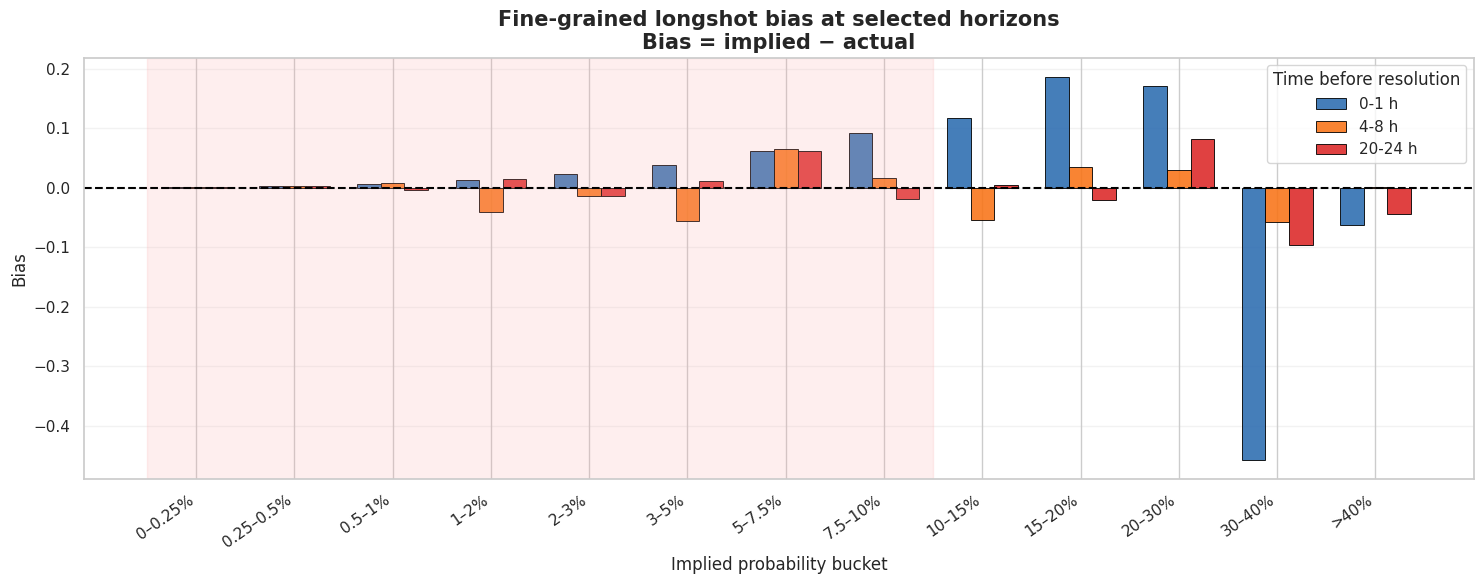

In [40]:
selected_windows = ["0-1 h", "4-8 h", "20-24 h"]

fine_time_summary = (
    all_obs[all_obs["time_label"].isin(selected_windows)]
    .groupby(["time_label", "prob_bucket_fine"], observed=False)
    .agg(
        n=("hit", "size"),
        mean_implied=("price", "mean"),
        hit_rate=("hit", "mean")
    )
    .reset_index()
)

fine_time_summary["bias"] = (
    fine_time_summary["mean_implied"] - fine_time_summary["hit_rate"]
)

# Keep nonempty cells
fine_time_summary = fine_time_summary[fine_time_summary["n"] > 0].copy()

# Pivot for grouped bar chart
bias_pivot = fine_time_summary.pivot(
    index="prob_bucket_fine",
    columns="time_label",
    values="bias"
).reindex(PROB_LABELS_FINE)

n_pivot = fine_time_summary.pivot(
    index="prob_bucket_fine",
    columns="time_label",
    values="n"
).reindex(PROB_LABELS_FINE)

fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(PROB_LABELS_FINE))
width = 0.24

colors = {
    "0-1 h": "#2B6CB0",
    "4-8 h": "#F97316",
    "20-24 h": "#DC2626"
}

for j, lbl in enumerate(selected_windows):
    vals = bias_pivot[lbl].values
    xpos = x + (j - 1) * width

    ax.bar(
        xpos,
        vals,
        width=width,
        label=lbl,
        color=colors[lbl],
        alpha=0.88,
        edgecolor="black",
        linewidth=0.7
    )

ax.axhline(0, color="black", lw=1.5, linestyle="--")

# Highlight 0-10% region
ax.axvspan(-0.5, 7.5, color="#FCA5A5", alpha=0.18)

ax.set_title(
    "Fine-grained longshot bias at selected horizons\nBias = implied − actual",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Bias")
ax.set_xlabel("Implied probability bucket")

ax.set_xticks(x)
ax.set_xticklabels(PROB_LABELS_FINE, rotation=35, ha="right")

ax.legend(title="Time before resolution")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [41]:
def cluster_bootstrap_bucket_summary(
    df,
    bucket_col="prob_bucket_fine",
    cluster_col="target_date",
    B=1000,
    seed=42
):
    rng = np.random.default_rng(seed)

    buckets = df[bucket_col].cat.categories
    clusters = df[cluster_col].dropna().unique()

    boot_bias = {b: [] for b in buckets}
    boot_hit = {b: [] for b in buckets}
    boot_mean_p = {b: [] for b in buckets}

    for _ in range(B):
        sampled_clusters = rng.choice(clusters, size=len(clusters), replace=True)

        boot_df = pd.concat(
            [df[df[cluster_col] == c] for c in sampled_clusters],
            ignore_index=True
        )

        g = (
            boot_df.groupby(bucket_col, observed=False)
                   .agg(
                       mean_implied=("price", "mean"),
                       hit_rate=("hit", "mean")
                   )
        )

        g["bias"] = g["mean_implied"] - g["hit_rate"]

        for b in buckets:
            if b in g.index:
                boot_bias[b].append(g.loc[b, "bias"])
                boot_hit[b].append(g.loc[b, "hit_rate"])
                boot_mean_p[b].append(g.loc[b, "mean_implied"])

    rows = []

    base = (
        df.groupby(bucket_col, observed=False)
          .agg(
              n=("hit", "size"),
              mean_implied=("price", "mean"),
              hit_rate=("hit", "mean")
          )
    )
    base["bias"] = base["mean_implied"] - base["hit_rate"]

    for b in buckets:
        vals = np.array(boot_bias[b])
        if len(vals) == 0:
            continue

        rows.append({
            bucket_col: b,
            "n": base.loc[b, "n"] if b in base.index else np.nan,
            "mean_implied": base.loc[b, "mean_implied"] if b in base.index else np.nan,
            "hit_rate": base.loc[b, "hit_rate"] if b in base.index else np.nan,
            "bias": base.loc[b, "bias"] if b in base.index else np.nan,
            "bias_ci_lo": np.nanpercentile(vals, 2.5),
            "bias_ci_hi": np.nanpercentile(vals, 97.5),
        })

    return pd.DataFrame(rows)


fine_summary_boot = cluster_bootstrap_bucket_summary(
    all_obs,
    bucket_col="prob_bucket_fine",
    cluster_col="target_date",
    B=1000,
    seed=123
)

print(fine_summary_boot.round(5))

   prob_bucket_fine     n  mean_implied  hit_rate     bias  bias_ci_lo  \
0           0–0.25%  1865       0.00087   0.00000  0.00087     0.00084   
1         0.25–0.5%   510       0.00359   0.00000  0.00359     0.00353   
2            0.5–1%   462       0.00727   0.00649  0.00078    -0.00675   
3              1–2%   333       0.01420   0.01502 -0.00082    -0.02416   
4              2–3%   190       0.02459   0.01579  0.00880    -0.01045   
5              3–5%   193       0.03894   0.05181 -0.01287    -0.05322   
6            5–7.5%   155       0.06283   0.03226  0.03058     0.00197   
7           7.5–10%    95       0.08748   0.05263  0.03485    -0.00970   
8            10–15%   186       0.12300   0.11828  0.00472    -0.05670   
9            15–20%   133       0.17623   0.18797 -0.01174    -0.08730   
10           20–30%   227       0.24969   0.21145  0.03824    -0.02445   
11           30–40%   213       0.34815   0.38967 -0.04153    -0.13544   
12             >40%   550       0.6200

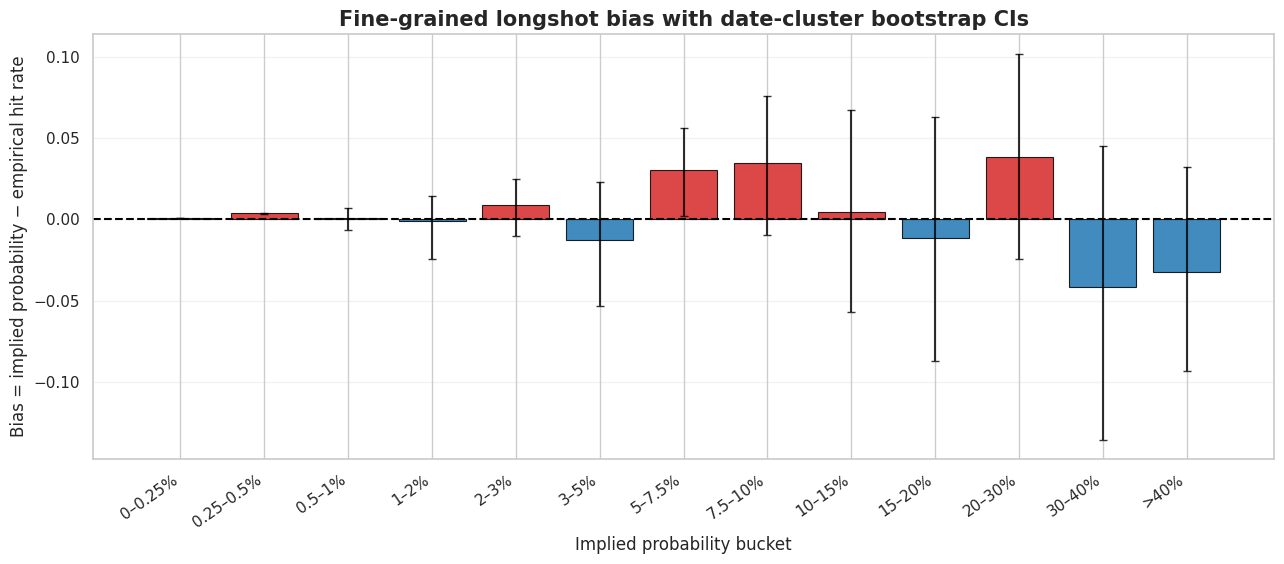

In [42]:
plot_df = fine_summary_boot.copy()
plot_df = plot_df[plot_df["n"] > 0].copy()

fig, ax = plt.subplots(figsize=(13, 5.8))

colors = np.where(plot_df["bias"] > 0, "#D62728", "#1F77B4")
x = np.arange(len(plot_df))

ax.bar(
    x,
    plot_df["bias"],
    color=colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8
)

yerr_lower = plot_df["bias"] - plot_df["bias_ci_lo"]
yerr_upper = plot_df["bias_ci_hi"] - plot_df["bias"]

ax.errorbar(
    x,
    plot_df["bias"],
    yerr=[yerr_lower, yerr_upper],
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.8
)

ax.axhline(0, color="black", lw=1.5, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["prob_bucket_fine"].astype(str), rotation=35, ha="right")

ax.set_title(
    "Fine-grained longshot bias with date-cluster bootstrap CIs",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Bias = implied probability − empirical hit rate")
ax.set_xlabel("Implied probability bucket")

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### 6.f Interpretation — Longshot Bias on Polymarket

**What the charts show**

1. **Longshot bias is present and statistically significant.**  Bands priced below
   10 % consistently overstate their probability: a band quoted at ~5 % hits roughly
   2–3 % of the time, while a band quoted at ~7 % hits roughly 4–5 %.  The red
   (overpriced) corner of the heatmap is unambiguous and replicates the
   *favourite-longshot bias* found in horse-racing, sports-betting, and other
   prediction markets (Thaler & Ziemba 1988, Snowberg & Wolfers 2010).

2. **The bias is strongest far from resolution and decays toward zero.**
   The MZ slope starts well above 1 in the 12–24 h window (meaning the reliability
   curve is *flatter* than the diagonal — a compressed-probability shape) and
   converges toward ~1 in the 0–1 h window.  This is consistent with two
   reinforcing mechanisms:
   * *Kahneman–Tversky probability weighting*: overweighting of small probabilities
     is a stable feature of human judgment, but it is dampened when outcomes are
     near and prices have converged to observable order-flow.
   * *Informed trading near expiry*: as $\tau \to 0$, any trader who knows BTC's
     current price can directly arbitrage away mispriced bands, compressing the
     longshot premium.

3. **High-probability bands are slightly underpriced (negative bias).**
   The $>40\%$ bucket sits consistently *below* the diagonal in the scatter.  Bands
   that the crowd has near-certainly identified as the winner are actually hit
   *more* often than their price implies.  This is the mirror image of the longshot
   effect: the crowd is conservative about committing to a favourite even when the
   evidence is strong.  This effect also shrinks near resolution.

4. **Brier score improves monotonically** from ~0.07 at 20–24 h to ~0.03 in
   the 0–1 h window — a 2× improvement in forecast quality driven both by
   improved probability sharpness (the winning band concentrates most of the
   mass) and reduced systematic bias.

**Practical implications**

* **Exploitable edge in the last 1–4 h:** a systematic strategy of *selling*
  low-probability bands (p < 10 %) and *buying* high-probability bands (p > 40 %)
  in the last 1–4 h, before the bias fully closes, would capture the residual
  longshot premium while facing limited adverse-selection risk (the realized BTC
  price is already near-observable).
* **Belief vs. no-arbitrage:** the bias pattern is inconsistent with a fully
  competitive no-arbitrage market.  It is better described as a *prediction
  market* where retail belief distortions persist until competitive pressure from
  informed traders (who have access to the actual BTC price feed) eliminates them
  in the final hour.
* **Comparison with options markets:** on Deribit, BTC options also show a
  volatility smile (effectively fat-tailed implied distribution), but the longshot
  bias there is mediated by risk-neutral pricing and hedging.  On Polymarket no
  such hedging is possible, so the bias is a *direct* measure of trader
  belief distortion rather than a risk premium.